# Medicine Survey Analysis Report

This notebook analyzes the survey stored in `Questionnaire (Responses) - Form responses 1.csv` and turns it into a full exploratory report.

It covers:

- data loading, cleaning, and standardization
- city normalization and analyst-defined city tier grouping
- socio-economic context using housing status
- device usage, lifestyle, and digital-adoption signals
- medicine burden, forgetfulness, current management, and reminder preferences
- product demand, willingness to buy, and spending expectations
- correlations, categorical associations, and practical design implications

Notes:

- The unsuffixed block of columns mostly describes elders through a caregiver/family-member response path.
- The `.1` suffixed block describes self-managed senior responses and is much smaller, so comparisons are directional rather than definitive.
- City tier labels are an **analyst-defined segmentation for comparison**, not an official government classification.

In [1]:
import math
import re
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = "Questionnaire (Responses) - Form responses 1.csv"
raw = pd.read_csv(DATA_PATH)

print(f"Raw dataset shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
display(raw.head(2))

Raw dataset shape: 52 rows x 43 columns


,Timestamp,Email address,You are filling this form as a:,What is your age?,What is your gender?,Which city do you live in?,Where do your elders live?,Which of the following items do your elders regularly use?,How do your elders usually spend their free time?,What is your age?.1,What is your gender?.1,Which city do you live in? .1,Where do you live?,Which of the following items do you regularly use?,How do you usually spend your free time?,How many tablets or pills does your elder take daily?,How many times a day does your elder take medicine?,How often does your elder forget to take their medicine on time?,At what time of day does your elder most often forget to take their medicine?,How many tablets or pills do you take daily?,How many times a day do you take medicine?,How often do you forget to take your medicine on time?,At what time of day do you most often forget to take your medicine?,Where are the medicines currently stored at home?,How are medicines currently organized?,How satisfied is your elder with the current way medicines are managed?,What problems does your elder face while managing medicines?,Where are the medicines currently stored at home?.1,How are medicines currently organized?.1,How satisfied are you with the current way medicines are managed?,What problems do you face while managing medicines?,How does your elder usually remember to take their medicine?,Which type of reminder would your elder find most comfortable and natural?,How do you usually remember to take medicine?,Which type of reminder would you feel most comfortable and natural?,Which of these products would your elder prefer for storing medicines?,For how many days would your elder like the product to store medicines?,"If this product was available today, would you buy it?","If you were to buy this product, how much would you spend?",Which of these products would you prefer for storing medicines?,For how many days would you like the product to store medicines?,"If this product was available today, would you buy it?.1","If you were to buy this product, how much would you spend?.1"
0,11/03/2026 17:36:26,NaN,Family member / Care-giver,18-30,Female,Rewari,House owned by the family,"Smartphone, Laptop/Computer, Two-wheeler, Household Appliances","Watching TV, Reading Newspaper/Book, Household Activities, Netflix & other OTT platforms, Social media platforms eg:...",NaN,NaN,NaN,NaN,NaN,NaN,1–2,Twice,Sometimes (a few times a month),No clear pattern,NaN,NaN,NaN,NaN,Bedroom table,"Kept in original strips, Polythenes/bags",3.0,"Forgetting the time, Reading small text, Remembering which medicine to take",NaN,NaN,NaN,NaN,"Fixed routine, No System",Voice reminder,NaN,NaN,Portable organiser,15 days,Likely,Under ₹500,NaN,NaN,NaN,NaN
1,11/03/2026 18:29:20,NaN,Family member / Care-giver (answer on behalf of the senior citizen),18-30,Male,Gandhinagar,Rented House,"Smartphone, Laptop/Computer, Two-wheeler, Household Appliances","Watching TV, Religious Activity, Netflix & other OTT platforms, Social media platforms eg: WhatsApp, Youtube, etc",NaN,NaN,NaN,NaN,NaN,NaN,1–2,Once,Rarely (pnce a month or less),Night,NaN,NaN,NaN,NaN,One fixed place,Kept in original strips,3.0,"Forgetting the time, Reading small text",NaN,NaN,NaN,NaN,Fixed routine,Mobile notification,NaN,NaN,"Portable organiser, Intregrated with a daily object",15 days,Yes,"₹2,000–5,000",NaN,NaN,NaN,NaN


## 1. Cleaning Framework

The survey contains two parallel answer flows and several messy text entries. This step standardizes:

- city names and capitalization
- multi-select answers
- housing-status interpretation
- ordinal encodings for medication burden, forgetfulness, buying intent, and budgets
- derived behavioral indices such as device adoption, digital engagement, and problem burden

In [2]:
CITY_ALIASES = {
    "bangalore": "Bengaluru",
    "bengaluru": "Bengaluru",
    "delhi": "Delhi",
    "new delhi": "Delhi",
    "vadodara": "Vadodara",
    "vadodara ": "Vadodara",
    "v a d o d a r a": "Vadodara",
    "v a d o d a r a ": "Vadodara",
    "gamdhinagar": "Gandhinagar",
    "gandhinagar": "Gandhinagar",
    "rewari haryana": "Rewari",
    "katihar bihar": "Katihar",
    "mumbai. gandhinagar": "Mumbai",
}

CITY_TIER_MAP = {
    "Ahmedabad": "Tier 1",
    "Bengaluru": "Tier 1",
    "Delhi": "Tier 1",
    "Kolkata": "Tier 1",
    "Mumbai": "Tier 1",
    "Pune": "Tier 1",
    "Agra": "Tier 2",
    "Anand": "Tier 2",
    "Bhavnagar": "Tier 2",
    "Bhopal": "Tier 2",
    "Gandhinagar": "Tier 2",
    "Udaipur": "Tier 2",
    "Vadodara": "Tier 2",
    "Valsad": "Tier 2",
    "Barwani": "Tier 3",
    "Katihar": "Tier 3",
    "Rewari": "Tier 3",
}

DEVICE_OPTIONS = [
    "Smartphone",
    "Laptop / Computer",
    "Car",
    "Two-wheeler",
    "Household Appliances",
]

LEISURE_REPLACEMENTS = {
    "Social media platforms eg: WhatsApp, Youtube, etc": "Social Media",
    "Netflix & other OTT platforms": "OTT Platforms",
    "Stock market, SIPs, Mutual Funds": "Stock Market / SIPs / Mutual Funds",
}

LEISURE_OPTIONS = [
    "Watching TV",
    "Reading Newspaper / Book",
    "Gardening",
    "Religious Activity",
    "Household Activities",
    "Stock Market / SIPs / Mutual Funds",
    "OTT Platforms",
    "Social Media",
    "Doing Nothing",
    "Smoking",
]

PROBLEM_OPTIONS = [
    "Forgetting the time",
    "Reading small text",
    "Organising medicines",
    "Opening packaging",
    "Remembering which medicine to take",
    "None of the above",
]

CURRENT_REMINDER_OPTIONS = [
    "Fixed routine",
    "Family / caregiver reminder",
    "Mobile phone alarm",
    "Written notes",
    "No system",
]

PREFERRED_REMINDER_OPTIONS = [
    "Voice reminder",
    "No reminder needed",
    "Beeping alarm",
    "Mobile notification",
    "Flashing light",
]

PRODUCT_REPLACEMENTS = {
    "Integrated with a daily object (e.g., clock, water bottle, etc.)": "Daily Object Integration",
    "Integrated with a daily object (eg. clock, water bottle, etc.)": "Daily Object Integration",
    "Intregrated with a daily object": "Daily Object Integration",
}

PRODUCT_OPTIONS = [
    "Portable organiser",
    "Automatic Pill Dispenser",
    "Robotic pill dispenser",
    "Daily Object Integration",
    "Monthly organiser",
]

PILLS_MAP = {"1–2": 1.5, "3–5": 4, "6–8": 7, "More than 8": 9}
TIMES_MAP = {"Once": 1, "Twice": 2, "Three times": 3, "Four or more times": 4}
FORGET_MAP = {
    "Never": 0,
    "Rarely (once a month or less)": 1,
    "Rarely (pnce a month or less)": 1,
    "Sometimes (a few times a month)": 2,
    "Often (weekly)": 3,
    "Very Often (almost daily)": 4,
}
BUY_MAP = {"No": 0, "Maybe": 1, "Likely": 2, "Yes": 3}
BUDGET_MAP = {
    "Not Applicable": 0,
    "Under ₹500": 1,
    "₹500–2,000": 2,
    "₹2,000–5,000": 3,
    "₹5,000–10,000": 4,
}
DAYS_MAP = {"1 day": 1, "7 days": 7, "15 days": 15, "30 days": 30}
TIER_CODE = {"Tier 1": 3, "Tier 2": 2, "Tier 3": 1, "Unclear": np.nan}
HOUSING_CODE = {
    "Own house": 4,
    "Family-owned house": 3,
    "Relative's house": 2,
    "Employer-provided house": 2,
    "Rented house": 1,
}
AGE_MAP_CAREGIVER = {"18-30": 1, "31-45": 2, "46-60": 3, "above 60": 4}
AGE_MAP_SELF = {"60-65": 1, "66-70": 2}
ROLE_NORMALIZATION = {
    "Family member / Care-giver": "Family member / Care-giver (answer on behalf of the senior citizen)",
}
CAREGIVER_ROLE = "Family member / Care-giver (answer on behalf of the senior citizen)"
SENIOR_ROLE = "Senior citizen (taking medicines by myself)"
BOTH_ROLE = "Both (I am a senior who also helps another person with medicines)"


def clean_text(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value


def clean_city(value):
    value = clean_text(value)
    if pd.isna(value):
        return np.nan
    lowered = value.replace("/", " ").strip().lower()
    lowered = re.sub(r"\s+", " ", lowered)
    if lowered in CITY_ALIASES:
        return CITY_ALIASES[lowered]
    if "." in value:
        first_part = re.split(r"[.,/]", value)[0]
        first_part = re.sub(r"\s+", " ", first_part).strip().lower()
        if first_part in CITY_ALIASES:
            return CITY_ALIASES[first_part]
        return first_part.title()
    return lowered.title()


def city_tier(value):
    if pd.isna(value):
        return "Unclear"
    return CITY_TIER_MAP.get(value, "Unclear")


def normalize_housing(value):
    value = clean_text(value)
    if pd.isna(value):
        return np.nan
    lowered = value.lower()
    if "rented" in lowered:
        return "Rented house"
    if "government" in lowered or "employee" in lowered:
        return "Employer-provided house"
    if "son" in lowered:
        return "Relative's house"
    if "family" in lowered:
        return "Family-owned house"
    if "own" in lowered:
        return "Own house"
    return value.title()


def replace_many(text, replacements):
    if pd.isna(text):
        return np.nan
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def parse_multiselect(value, replacements=None, rename_map=None):
    value = clean_text(value)
    if pd.isna(value):
        return np.nan
    if replacements:
        value = replace_many(value, replacements)
    parts = [part.strip() for part in value.split(",") if part.strip()]
    cleaned = []
    for part in parts:
        renamed = rename_map.get(part, part) if rename_map else part
        cleaned.append(renamed)
    deduped = []
    for part in cleaned:
        if part not in deduped:
            deduped.append(part)
    return deduped


def slugify(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


def add_indicator_columns(frame, list_column, categories, prefix):
    for category in categories:
        col = f"{prefix}_{slugify(category)}"
        frame[col] = frame[list_column].apply(
            lambda values: int(category in values) if isinstance(values, list) else np.nan
        )

In [3]:
def respondent_share(frame, column, categories):
    out = []
    valid = frame[column].apply(lambda values: isinstance(values, list))
    n = int(valid.sum())
    for category in categories:
        share = frame.loc[valid, column].apply(lambda values: category in values).mean() * 100 if n else np.nan
        out.append({"category": category, "respondent_share_pct": share, "n_answers": n})
    return pd.DataFrame(out).sort_values("respondent_share_pct", ascending=False)


def encode_primary(values):
    return values[0] if isinstance(values, list) and values else np.nan


def band_problem(score):
    if pd.isna(score):
        return np.nan
    if score == 0:
        return "No stated problem"
    if score <= 2:
        return "1-2 problems"
    return "3+ problems"


def band_digital(score):
    if pd.isna(score):
        return np.nan
    if score <= 1:
        return "Low"
    if score <= 3:
        return "Medium"
    return "High"


raw["role_clean"] = raw["You are filling this form as a:"].replace(ROLE_NORMALIZATION)
caregiver_intended = raw["role_clean"].isin([CAREGIVER_ROLE, BOTH_ROLE])
senior_intended = raw["role_clean"].isin([SENIOR_ROLE, BOTH_ROLE])

elder = raw.loc[caregiver_intended, [
        "You are filling this form as a:",
        "What is your age?",
        "What is your gender?",
        "Which city do you live in? ",
        "Where do your elders live?",
        "Which of the following items do your elders regularly use?",
        "How do your elders usually spend their free time?",
        "How many tablets or pills does your elder take daily?",
        "How many times a day does your elder take medicine?",
        "How often does your elder forget to take their medicine on time?  ",
        "At what time of day does your elder most often forget to take their medicine?",
        "Where are the medicines currently stored at home?",
        "How are medicines currently organized?",
        "How satisfied is your elder with the current way medicines are managed? ",
        "What problems does your elder face while managing medicines?",
        "How does your elder usually remember to take their medicine?",
        "Which type of reminder would your elder find most comfortable and natural? ",
        "Which of these products would your elder prefer for storing medicines? ",
        "For how many days would your elder like the product to store medicines?",
        "If this product was available today, would you buy it?",
        "If you were to buy this product, how much would you spend?",
]].copy()

elder.columns = [
    "role",
    "respondent_age_group",
    "respondent_gender",
    "respondent_city_raw",
    "elder_housing_raw",
    "items_raw",
    "free_time_raw",
    "pills_daily_raw",
    "times_daily_raw",
    "forgetfulness_raw",
    "forget_time_raw",
    "storage_raw",
    "organization_raw",
    "satisfaction_raw",
    "problems_raw",
    "current_reminder_raw",
    "preferred_reminder_raw",
    "product_pref_raw",
    "days_pref_raw",
    "buy_intent_raw",
    "budget_raw",
]
elder["role"] = elder["role"].replace(ROLE_NORMALIZATION)
elder = elder.reset_index(drop=True)

self_managed = raw.loc[senior_intended, [
        "You are filling this form as a:",
        "What is your age?.1",
        "What is your gender?.1",
        "Which city do you live in? .1",
        "Where do you live?",
        "Which of the following items do you regularly use?",
        "How do you usually spend your free time?",
        "How many tablets or pills do you take daily?",
        "How many times a day do you take medicine?",
        "How often do you forget to take your medicine on time?",
        "At what time of day do you most often forget to take your medicine?",
        "Where are the medicines currently stored at home?.1",
        "How are medicines currently organized?.1",
        "How satisfied are you with the current way medicines are managed?  ",
        "What problems do you face while managing medicines?",
        "How do you usually remember to take medicine?",
        "Which type of reminder would you feel most comfortable and natural? ",
        "Which of these products would you prefer for storing medicines?",
        "For how many days would you like the product to store medicines?",
        "If this product was available today, would you buy it?.1",
        "If you were to buy this product, how much would you spend?.1",
]].copy()

self_managed.columns = [
    "role",
    "respondent_age_group",
    "respondent_gender",
    "respondent_city_raw",
    "elder_housing_raw",
    "items_raw",
    "free_time_raw",
    "pills_daily_raw",
    "times_daily_raw",
    "forgetfulness_raw",
    "forget_time_raw",
    "storage_raw",
    "organization_raw",
    "satisfaction_raw",
    "problems_raw",
    "current_reminder_raw",
    "preferred_reminder_raw",
    "product_pref_raw",
    "days_pref_raw",
    "buy_intent_raw",
    "budget_raw",
]
self_managed["role"] = self_managed["role"].replace(ROLE_NORMALIZATION)
self_managed = self_managed.reset_index(drop=True)


def enrich(frame, age_map):
    frame = frame.copy()
    frame["respondent_city_clean"] = frame["respondent_city_raw"].apply(clean_city)
    frame["city_tier"] = frame["respondent_city_clean"].apply(city_tier)
    frame["city_tier_code"] = frame["city_tier"].map(TIER_CODE)
    frame["housing_status"] = frame["elder_housing_raw"].apply(normalize_housing)
    frame["housing_code"] = frame["housing_status"].map(HOUSING_CODE)
    frame["device_list"] = frame["items_raw"].apply(
        lambda value: parse_multiselect(value, rename_map={"Laptop/Computer": "Laptop / Computer"})
    )
    frame["leisure_list"] = frame["free_time_raw"].apply(
        lambda value: parse_multiselect(
            value,
            replacements=LEISURE_REPLACEMENTS,
            rename_map={
                "Reading Newspaper/Book": "Reading Newspaper / Book",
                "smoking": "Smoking",
                "Doing nothing": "Doing Nothing",
            },
        )
    )
    frame["problem_list"] = frame["problems_raw"].apply(parse_multiselect)
    frame["current_reminder_list"] = frame["current_reminder_raw"].apply(
        lambda value: parse_multiselect(
            value,
            rename_map={
                "Family/caregiver reminder": "Family / caregiver reminder",
                "No System": "No system",
            },
        )
    )
    frame["preferred_reminder_list"] = frame["preferred_reminder_raw"].apply(parse_multiselect)
    frame["product_pref_list"] = frame["product_pref_raw"].apply(
        lambda value: parse_multiselect(value, replacements=PRODUCT_REPLACEMENTS)
    )
    frame["storage_list"] = frame["storage_raw"].apply(parse_multiselect)
    frame["organization_list"] = frame["organization_raw"].apply(parse_multiselect)
    frame["device_adoption_score"] = frame["device_list"].apply(lambda values: len(values) if isinstance(values, list) else np.nan)
    frame["digital_engagement_score"] = (
        frame["device_list"].apply(
            lambda values: int("Smartphone" in values) + int("Laptop / Computer" in values) if isinstance(values, list) else np.nan
        )
        + frame["leisure_list"].apply(
            lambda values: int("OTT Platforms" in values) + int("Social Media" in values) if isinstance(values, list) else np.nan
        )
    )
    frame["activity_variety_score"] = frame["leisure_list"].apply(lambda values: len(values) if isinstance(values, list) else np.nan)
    frame["problem_burden_score"] = frame["problem_list"].apply(
        lambda values: len([value for value in values if value != "None of the above"]) if isinstance(values, list) else np.nan
    )
    frame["problem_burden_band"] = frame["problem_burden_score"].apply(band_problem)
    frame["digital_band"] = frame["digital_engagement_score"].apply(band_digital)
    frame["pills_daily_num"] = frame["pills_daily_raw"].map(PILLS_MAP)
    frame["times_daily_num"] = frame["times_daily_raw"].map(TIMES_MAP)
    frame["forgetfulness_num"] = frame["forgetfulness_raw"].map(FORGET_MAP)
    frame["satisfaction_num"] = pd.to_numeric(frame["satisfaction_raw"], errors="coerce")
    frame["buy_intent_num"] = frame["buy_intent_raw"].map(BUY_MAP)
    frame["budget_num"] = frame["budget_raw"].map(BUDGET_MAP)
    frame["days_pref_num"] = frame["days_pref_raw"].map(DAYS_MAP)
    frame["respondent_age_code"] = frame["respondent_age_group"].map(age_map)
    frame["preferred_reminder_primary"] = frame["preferred_reminder_list"].apply(encode_primary)
    frame["preferred_product_primary"] = frame["product_pref_list"].apply(encode_primary)
    frame["multi_city_input"] = frame["respondent_city_raw"].fillna("").str.contains(r"[./,]", regex=True).astype(int)
    return frame


elder = enrich(elder, AGE_MAP_CAREGIVER)
self_managed = enrich(self_managed, AGE_MAP_SELF)

add_indicator_columns(elder, "device_list", DEVICE_OPTIONS, "device")
add_indicator_columns(self_managed, "device_list", DEVICE_OPTIONS, "device")
add_indicator_columns(elder, "leisure_list", LEISURE_OPTIONS, "leisure")
add_indicator_columns(self_managed, "leisure_list", LEISURE_OPTIONS, "leisure")
add_indicator_columns(elder, "problem_list", PROBLEM_OPTIONS, "problem")
add_indicator_columns(self_managed, "problem_list", PROBLEM_OPTIONS, "problem")
add_indicator_columns(elder, "preferred_reminder_list", PREFERRED_REMINDER_OPTIONS, "preferred")
add_indicator_columns(self_managed, "preferred_reminder_list", PREFERRED_REMINDER_OPTIONS, "preferred")

print(f"Caregiver-path respondents intended for sections 2/4/6/8/10: {len(elder)}")
print(f"Senior/Both respondents intended for sections 3/5/7/9/11: {len(self_managed)}")

Caregiver-path respondents intended for sections 2/4/6/8/10: 48
Senior/Both respondents intended for sections 3/5/7/9/11: 7


## 2. Survey Structure and Data Quality

The form uses branching. Questions from the non-selected pathway are **not missing data**; they are **not applicable by design**.

This section rebuilds the survey as two intended profiles:

- caregiver pathway: sections `2/4/6/8/10`
- senior or both pathway: sections `3/5/7/9/11`

,segment,n,note
0,All survey rows,52,Every submitted response
1,Caregiver pathway intended,48,Caregiver + Both roles
2,Senior/Both pathway intended,7,Senior citizen + Both roles
3,Caregiver pathway with any caregiver answer,46,Excludes branch-inapplicable fields
4,Senior/Both pathway with any self answer,7,Excludes branch-inapplicable fields


,role,count
0,Family member / Care-giver (answer on behalf of the senior citizen),45
1,Senior citizen (taking medicines by myself),4
2,Both (I am a senior who also helps another person with medicines),3


,profile,section,intended_respondents,avg_question_completion_pct,respondents_with_any_answer_pct
0,Caregiver pathway,Section 2: About You and Your Elders,48,92.4,93.8
1,Caregiver pathway,Section 4: Medicine Routine,48,95.8,95.8
2,Caregiver pathway,Section 6: Storage and Organization,48,95.8,95.8
3,Caregiver pathway,Section 8: Reminder Methods,48,95.8,95.8
4,Caregiver pathway,Section 10: Design Preferences,48,95.8,95.8
5,Senior/Both pathway,Section 3: About You,7,100.0,100.0
6,Senior/Both pathway,Section 5: Medication Routine,7,85.7,85.7
7,Senior/Both pathway,Section 7: Storage and Organization,7,85.7,85.7
8,Senior/Both pathway,Section 9: Reminder Methods,7,85.7,85.7
9,Senior/Both pathway,Section 11: Design Preferences,7,85.7,85.7


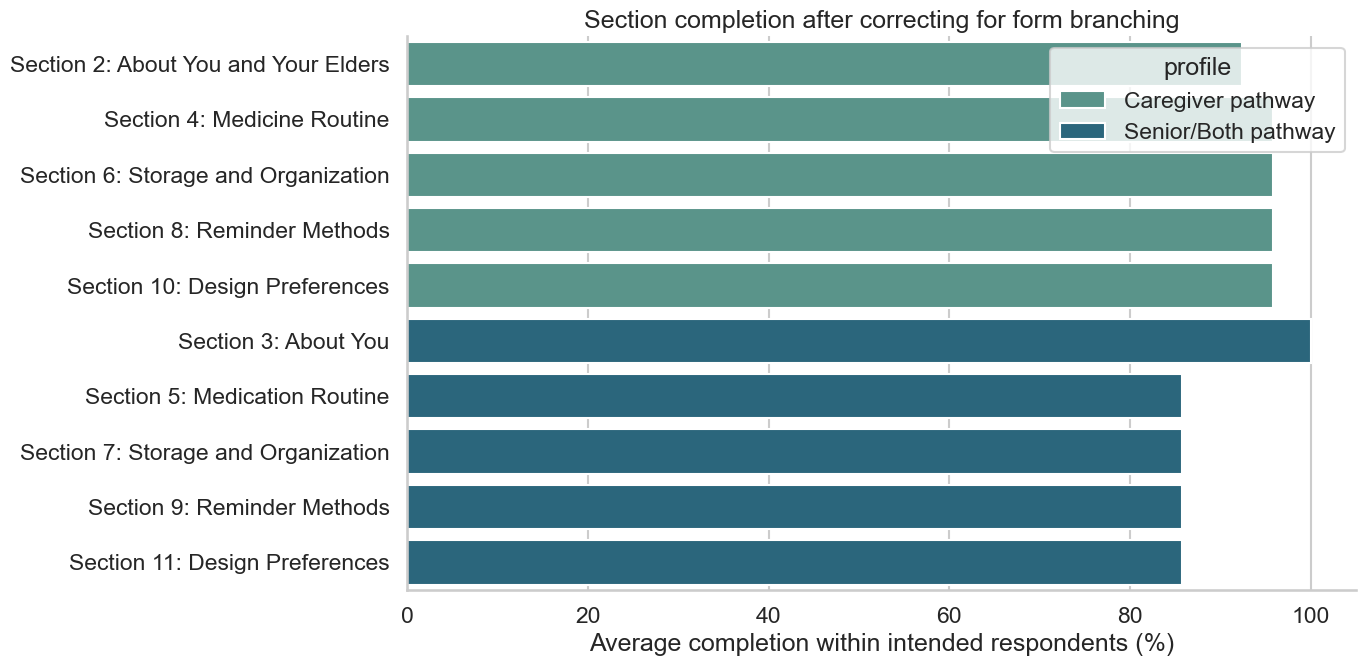

,respondent_city_raw,respondent_city_clean,city_tier
0,Agra,Agra,Tier 2
1,Ahmedabad,Ahmedabad,Tier 1
2,Ahmedabad,Ahmedabad,Tier 1
3,Anand,Anand,Tier 2
4,Barwani,Barwani,Tier 3
5,Bangalore,Bengaluru,Tier 1
6,Bengaluru,Bengaluru,Tier 1
7,Bengaluru,Bengaluru,Tier 1
8,Bhavnagar,Bhavnagar,Tier 2
9,Bhopal,Bhopal,Tier 2


In [4]:
caregiver_sections = {
    "Section 2: About You and Your Elders": [
        "What is your age?",
        "What is your gender?",
        "Which city do you live in? ",
        "Where do your elders live?",
        "Which of the following items do your elders regularly use?",
        "How do your elders usually spend their free time?",
    ],
    "Section 4: Medicine Routine": [
        "How many tablets or pills does your elder take daily?",
        "How many times a day does your elder take medicine?",
        "How often does your elder forget to take their medicine on time?  ",
        "At what time of day does your elder most often forget to take their medicine?",
    ],
    "Section 6: Storage and Organization": [
        "Where are the medicines currently stored at home?",
        "How are medicines currently organized?",
        "How satisfied is your elder with the current way medicines are managed? ",
        "What problems does your elder face while managing medicines?",
    ],
    "Section 8: Reminder Methods": [
        "How does your elder usually remember to take their medicine?",
        "Which type of reminder would your elder find most comfortable and natural? ",
    ],
    "Section 10: Design Preferences": [
        "Which of these products would your elder prefer for storing medicines? ",
        "For how many days would your elder like the product to store medicines?",
        "If this product was available today, would you buy it?",
        "If you were to buy this product, how much would you spend?",
    ],
}

senior_sections = {
    "Section 3: About You": [
        "What is your age?.1",
        "What is your gender?.1",
        "Which city do you live in? .1",
        "Where do you live?",
        "Which of the following items do you regularly use?",
        "How do you usually spend your free time?",
    ],
    "Section 5: Medication Routine": [
        "How many tablets or pills do you take daily?",
        "How many times a day do you take medicine?",
        "How often do you forget to take your medicine on time?",
        "At what time of day do you most often forget to take your medicine?",
    ],
    "Section 7: Storage and Organization": [
        "Where are the medicines currently stored at home?.1",
        "How are medicines currently organized?.1",
        "How satisfied are you with the current way medicines are managed?  ",
        "What problems do you face while managing medicines?",
    ],
    "Section 9: Reminder Methods": [
        "How do you usually remember to take medicine?",
        "Which type of reminder would you feel most comfortable and natural? ",
    ],
    "Section 11: Design Preferences": [
        "Which of these products would you prefer for storing medicines?",
        "For how many days would you like the product to store medicines?",
        "If this product was available today, would you buy it?.1",
        "If you were to buy this product, how much would you spend?.1",
    ],
}

sample_overview = pd.DataFrame(
    [
        {"segment": "All survey rows", "n": len(raw), "note": "Every submitted response"},
        {"segment": "Caregiver pathway intended", "n": int(caregiver_intended.sum()), "note": "Caregiver + Both roles"},
        {"segment": "Senior/Both pathway intended", "n": int(senior_intended.sum()), "note": "Senior citizen + Both roles"},
        {"segment": "Caregiver pathway with any caregiver answer", "n": int(raw.loc[caregiver_intended, sum(caregiver_sections.values(), [])].notna().any(axis=1).sum()), "note": "Excludes branch-inapplicable fields"},
        {"segment": "Senior/Both pathway with any self answer", "n": int(raw.loc[senior_intended, sum(senior_sections.values(), [])].notna().any(axis=1).sum()), "note": "Excludes branch-inapplicable fields"},
    ]
)
display(sample_overview)

role_counts = raw["role_clean"].value_counts(dropna=False).rename_axis("role").reset_index(name="count")
display(role_counts)

section_completion_rows = []
for profile, mask, sections in [
    ("Caregiver pathway", caregiver_intended, caregiver_sections),
    ("Senior/Both pathway", senior_intended, senior_sections),
]:
    for section_name, cols in sections.items():
        applicable = raw.loc[mask, cols]
        section_completion_rows.append(
            {
                "profile": profile,
                "section": section_name,
                "intended_respondents": int(mask.sum()),
                "avg_question_completion_pct": applicable.notna().mean().mean() * 100,
                "respondents_with_any_answer_pct": applicable.notna().any(axis=1).mean() * 100,
            }
        )

section_completion = pd.DataFrame(section_completion_rows).round(1)
display(section_completion)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=section_completion,
    x="avg_question_completion_pct",
    y="section",
    hue="profile",
    palette="crest",
)
plt.title("Section completion after correcting for form branching")
plt.xlabel("Average completion within intended respondents (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

city_cleaning_preview = (
    pd.concat(
        [
            elder[["respondent_city_raw", "respondent_city_clean", "city_tier"]],
            self_managed[["respondent_city_raw", "respondent_city_clean", "city_tier"]],
        ]
    )
    .drop_duplicates()
    .sort_values(["respondent_city_clean", "respondent_city_raw"])
    .reset_index(drop=True)
)
display(city_cleaning_preview)

The city-cleaning table shows that inconsistent casing and spelling were standardized before analysis. A few entries contained two places in one answer; those are treated as ambiguous and reduced to the primary readable city for grouping.

## 3. Demographic and Geographic Context

This section profiles who answered the survey and what geographic context surrounds the responses. Since the city field belongs mainly to the person filling the form, it works best as an **urban-context proxy** rather than a guaranteed elder residence field.

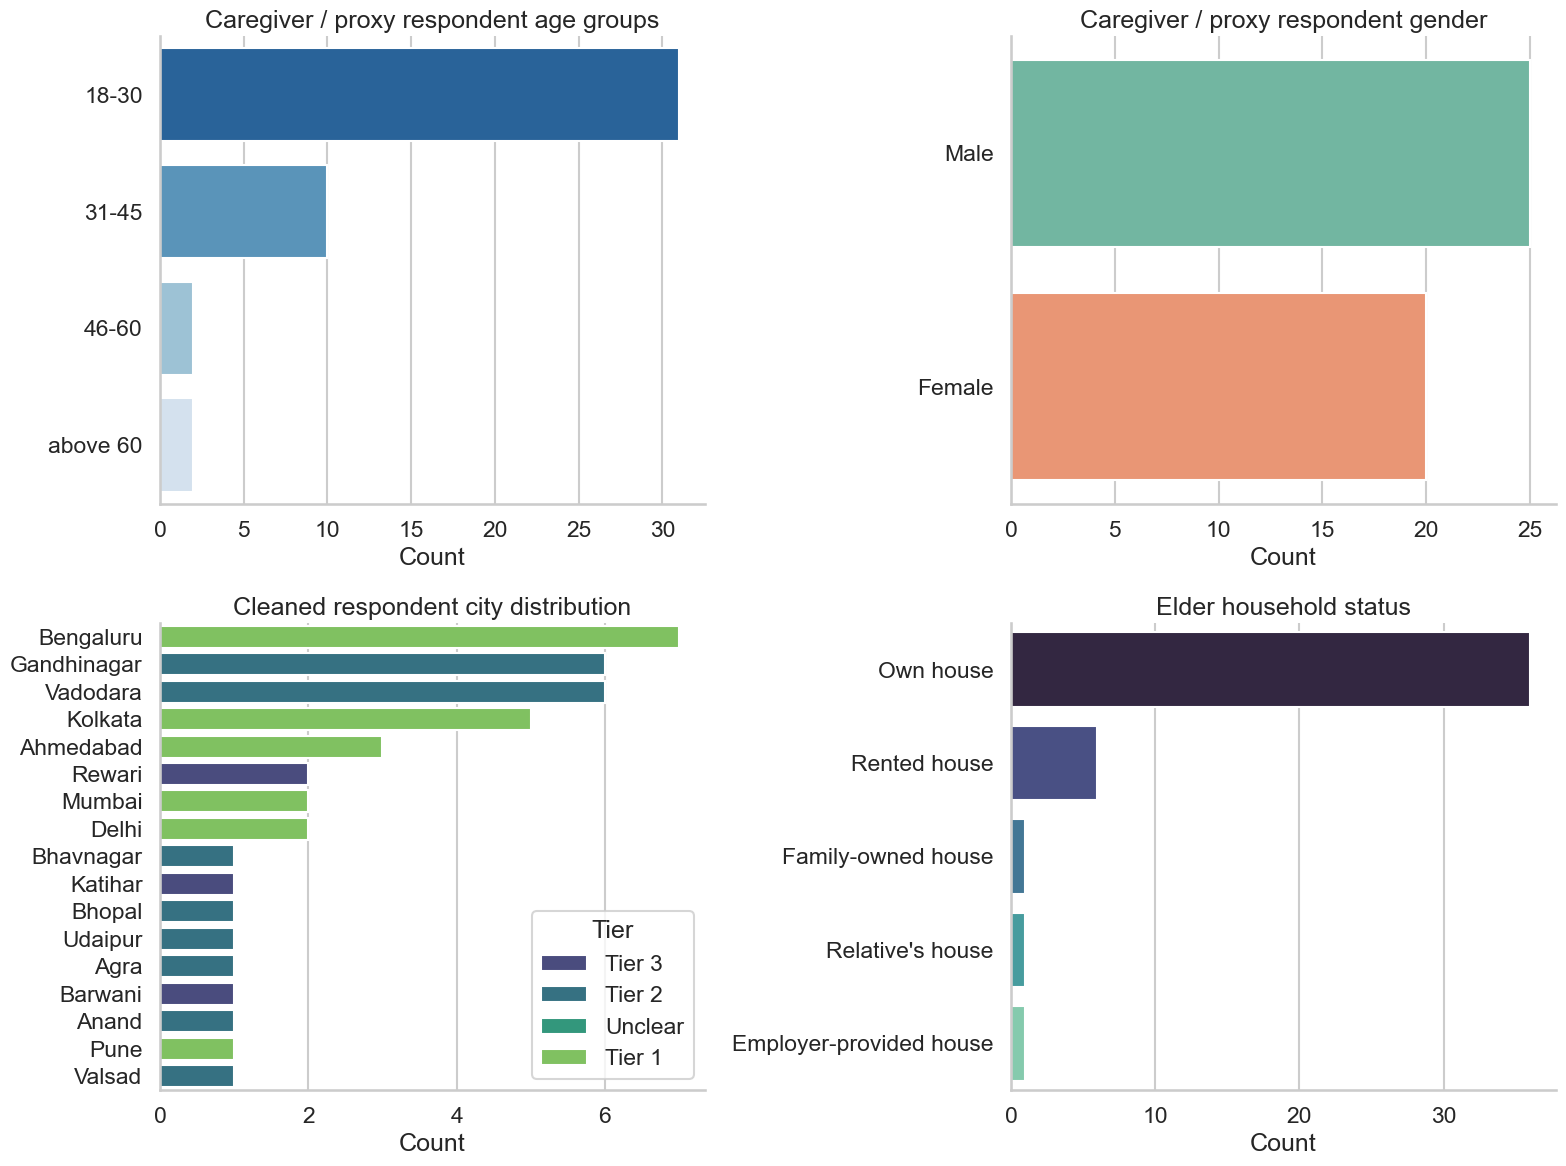

,respondents,avg_device_adoption,avg_digital_engagement,likely_or_yes_share
city_tier,,,,
Tier 1,20,2.30,1.65,50.00
Tier 2,18,2.33,1.72,38.89
Unclear,6,3.67,2.00,0.00
Tier 3,4,2.75,2.00,75.00


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(
    data=elder,
    y="respondent_age_group",
    order=elder["respondent_age_group"].value_counts().index,
    palette="Blues_r",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Caregiver / proxy respondent age groups")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("")

sns.countplot(
    data=elder,
    y="respondent_gender",
    order=elder["respondent_gender"].value_counts().index,
    palette="Set2",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Caregiver / proxy respondent gender")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("")

city_order = elder["respondent_city_clean"].value_counts().index
sns.countplot(
    data=elder,
    y="respondent_city_clean",
    order=city_order,
    hue="city_tier",
    palette="viridis",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Cleaned respondent city distribution")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("")
axes[1, 0].legend(title="Tier")

sns.countplot(
    data=elder,
    y="housing_status",
    order=elder["housing_status"].value_counts().index,
    palette="mako",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Elder household status")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

tier_summary = (
    elder.groupby("city_tier")
    .agg(
        respondents=("city_tier", "size"),
        avg_device_adoption=("device_adoption_score", "mean"),
        avg_digital_engagement=("digital_engagement_score", "mean"),
        likely_or_yes_share=("buy_intent_raw", lambda s: s.isin(["Likely", "Yes"]).mean() * 100),
    )
    .round(2)
    .sort_values("respondents", ascending=False)
)
display(tier_summary)

Housing status is valuable here as a socio-economic context variable. It does not measure wealth precisely, but it can still indicate stability, independence, and the likely permanence of in-home medicine-storage setups.

## 4. Device Usage, Lifestyle, and Adaptation to Newer Standards

These visuals translate the multi-select responses into adoption rates. The goal is to understand:

- how common smartphones and other devices are
- whether digital leisure habits are present
- whether more urban contexts show stronger modern-usage signals

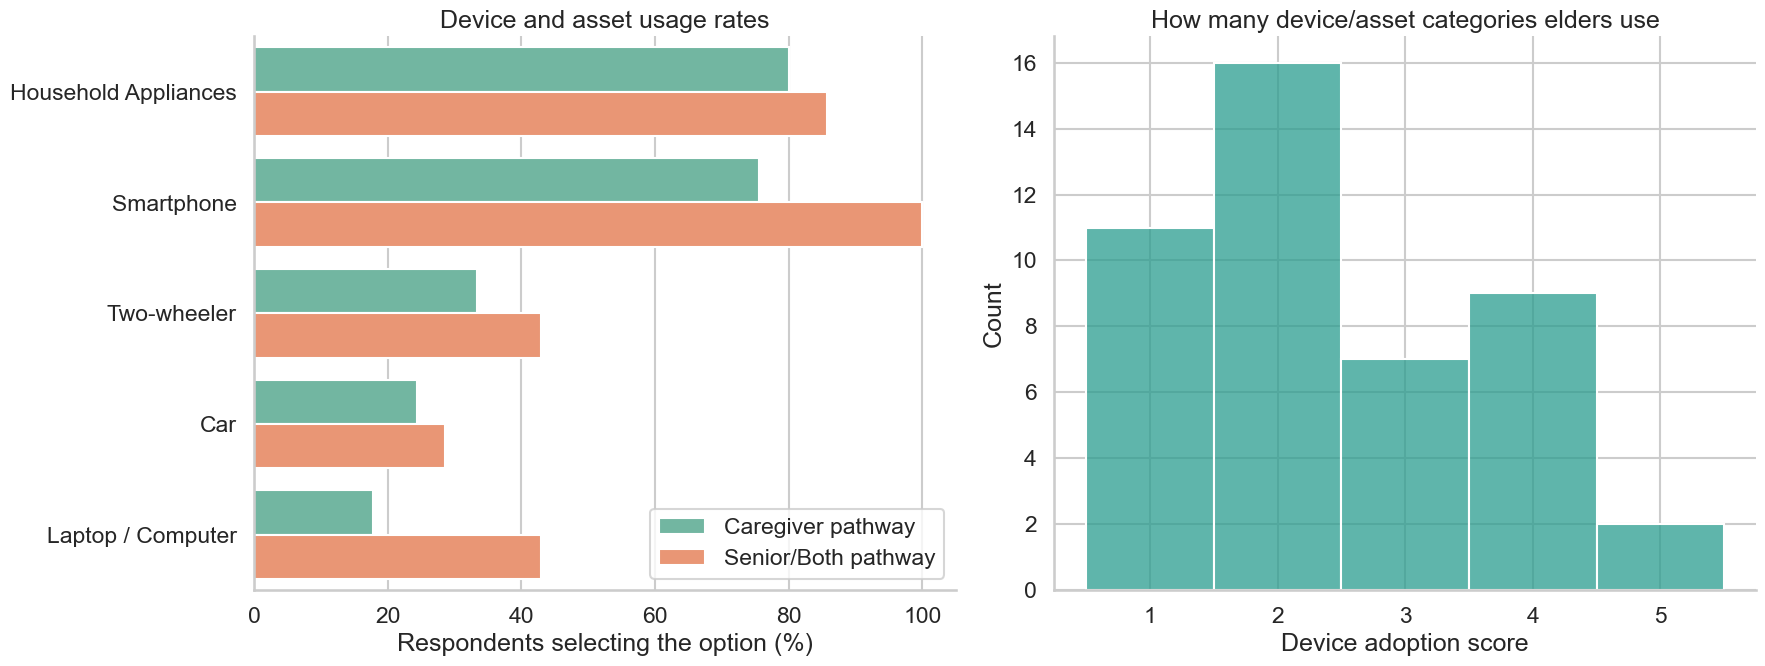

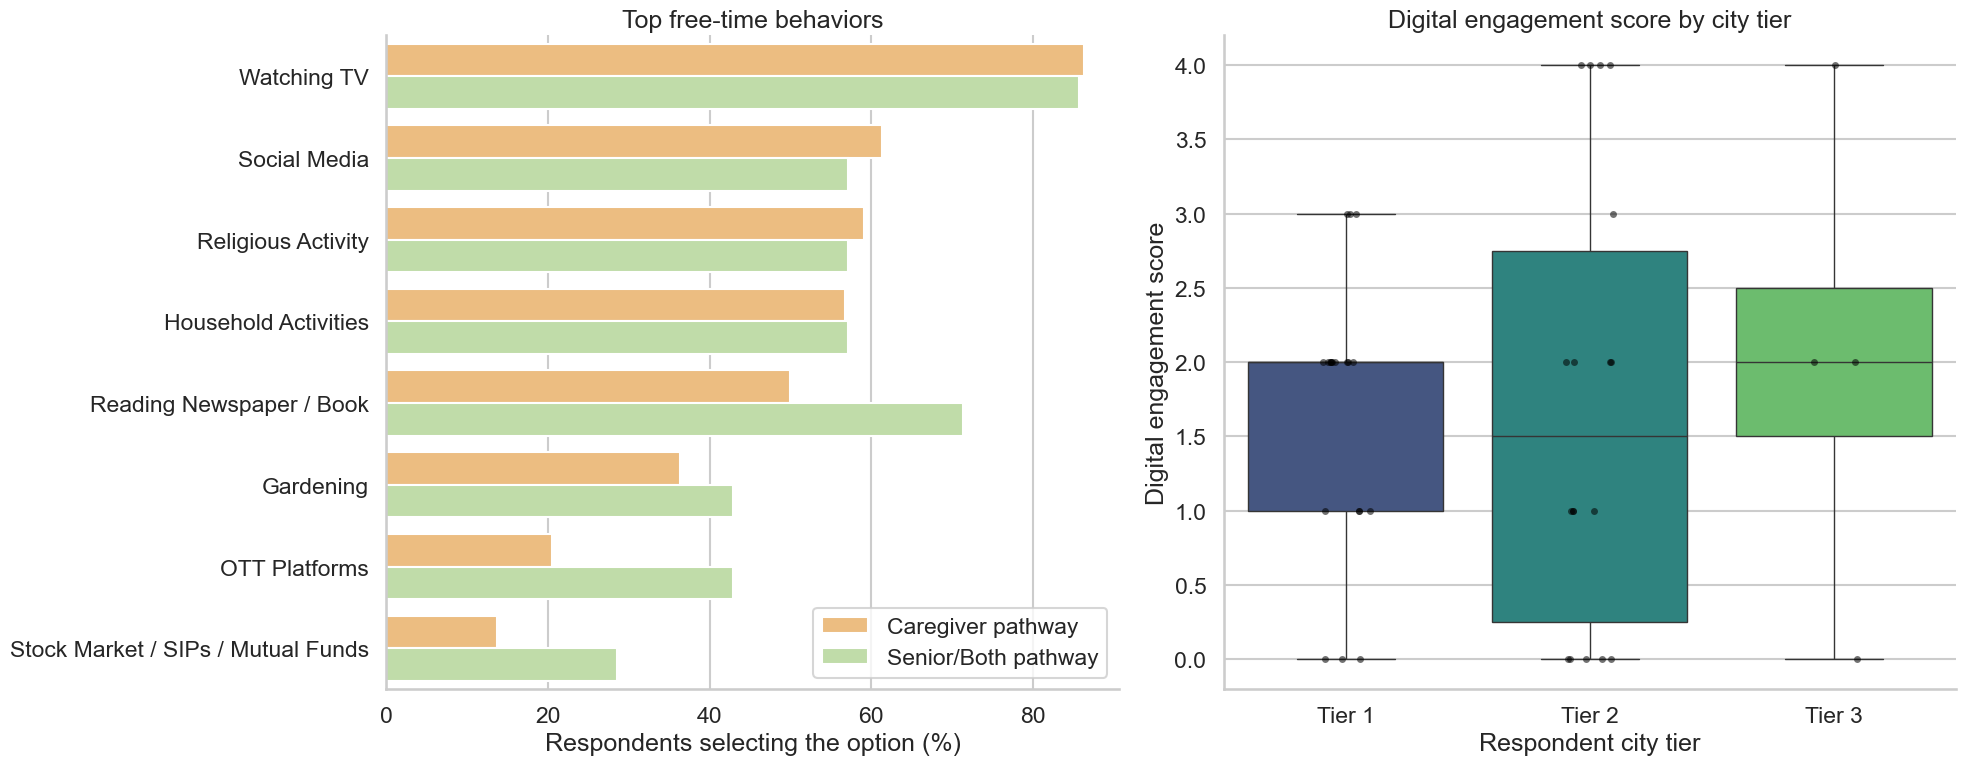

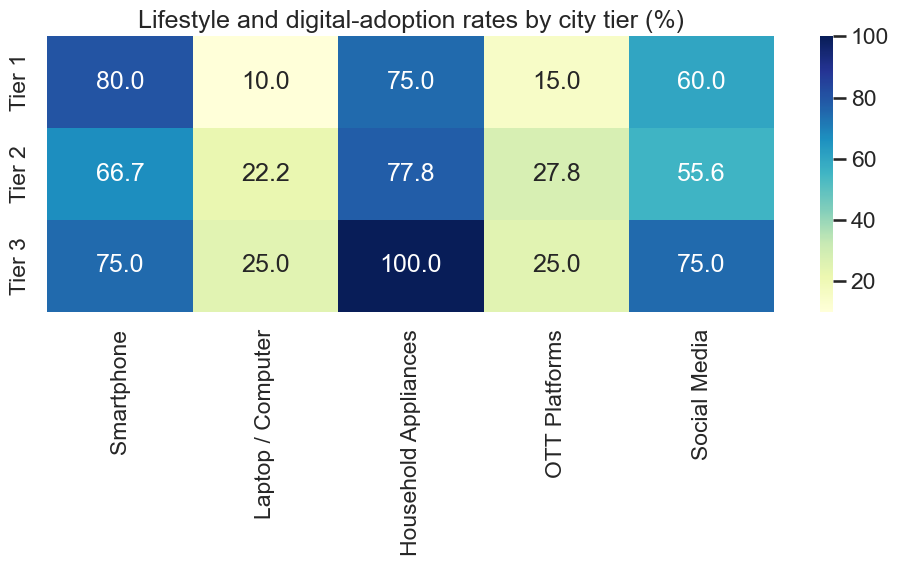

,category,respondent_share_pct,n_answers
4,Household Appliances,80.000000,45
0,Smartphone,75.555556,45
3,Two-wheeler,33.333333,45
2,Car,24.444444,45
1,Laptop / Computer,17.777778,45


,category,respondent_share_pct,n_answers
0,Watching TV,86.363636,44
7,Social Media,61.363636,44
3,Religious Activity,59.090909,44
4,Household Activities,56.818182,44
1,Reading Newspaper / Book,50.000000,44
2,Gardening,36.363636,44
6,OTT Platforms,20.454545,44
5,Stock Market / SIPs / Mutual Funds,13.636364,44
8,Doing Nothing,2.272727,44
9,Smoking,2.272727,44


In [6]:
device_compare = []
for label, frame in [("Caregiver pathway", elder), ("Senior/Both pathway", self_managed)]:
    shares = respondent_share(frame, "device_list", DEVICE_OPTIONS)
    shares["segment"] = label
    device_compare.append(shares)
device_compare = pd.concat(device_compare, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=device_compare,
    x="respondent_share_pct",
    y="category",
    hue="segment",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Device and asset usage rates")
axes[0].set_xlabel("Respondents selecting the option (%)")
axes[0].set_ylabel("")
axes[0].legend(title="")

sns.histplot(elder["device_adoption_score"], discrete=True, color="#2A9D8F", ax=axes[1])
axes[1].set_title("How many device/asset categories elders use")
axes[1].set_xlabel("Device adoption score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

leisure_compare = []
for label, frame in [("Caregiver pathway", elder), ("Senior/Both pathway", self_managed)]:
    shares = respondent_share(frame, "leisure_list", LEISURE_OPTIONS)
    shares["segment"] = label
    leisure_compare.append(shares)
leisure_compare = pd.concat(leisure_compare, ignore_index=True)

top_leisure = (
    leisure_compare.groupby("category")["respondent_share_pct"]
    .max()
    .sort_values(ascending=False)
    .head(8)
    .index
)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.barplot(
    data=leisure_compare[leisure_compare["category"].isin(top_leisure)],
    x="respondent_share_pct",
    y="category",
    hue="segment",
    palette="Spectral",
    ax=axes[0],
)
axes[0].set_title("Top free-time behaviors")
axes[0].set_xlabel("Respondents selecting the option (%)")
axes[0].set_ylabel("")
axes[0].legend(title="")

sns.boxplot(
    data=elder,
    x="city_tier",
    y="digital_engagement_score",
    order=["Tier 1", "Tier 2", "Tier 3"],
    palette="viridis",
    ax=axes[1],
)
sns.stripplot(
    data=elder,
    x="city_tier",
    y="digital_engagement_score",
    order=["Tier 1", "Tier 2", "Tier 3"],
    color="black",
    alpha=0.55,
    ax=axes[1],
)
axes[1].set_title("Digital engagement score by city tier")
axes[1].set_xlabel("Respondent city tier")
axes[1].set_ylabel("Digital engagement score")

plt.tight_layout()
plt.show()

selected_flags = {
    "Smartphone": "device_smartphone",
    "Laptop / Computer": "device_laptop_computer",
    "Household Appliances": "device_household_appliances",
    "OTT Platforms": "leisure_ott_platforms",
    "Social Media": "leisure_social_media",
}
adoption_by_tier = pd.DataFrame(
    {
        label: elder.groupby("city_tier")[column].mean().mul(100)
        for label, column in selected_flags.items()
    }
).reindex(["Tier 1", "Tier 2", "Tier 3"])

plt.figure(figsize=(10, 6))
sns.heatmap(adoption_by_tier, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Lifestyle and digital-adoption rates by city tier (%)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(respondent_share(elder, "device_list", DEVICE_OPTIONS))
display(respondent_share(elder, "leisure_list", LEISURE_OPTIONS).head(10))

Smartphones are especially important in this survey because they can act as the bridge between familiar behavior and medication-support interventions. Household appliances are included as a broader comfort-with-modern-convenience signal, even though they are not purely digital.

## 5. Medication Burden, Forgetfulness, and Practical Friction

This section looks at how heavy the medication load is, when people forget, and what kind of problems they face in day-to-day management.

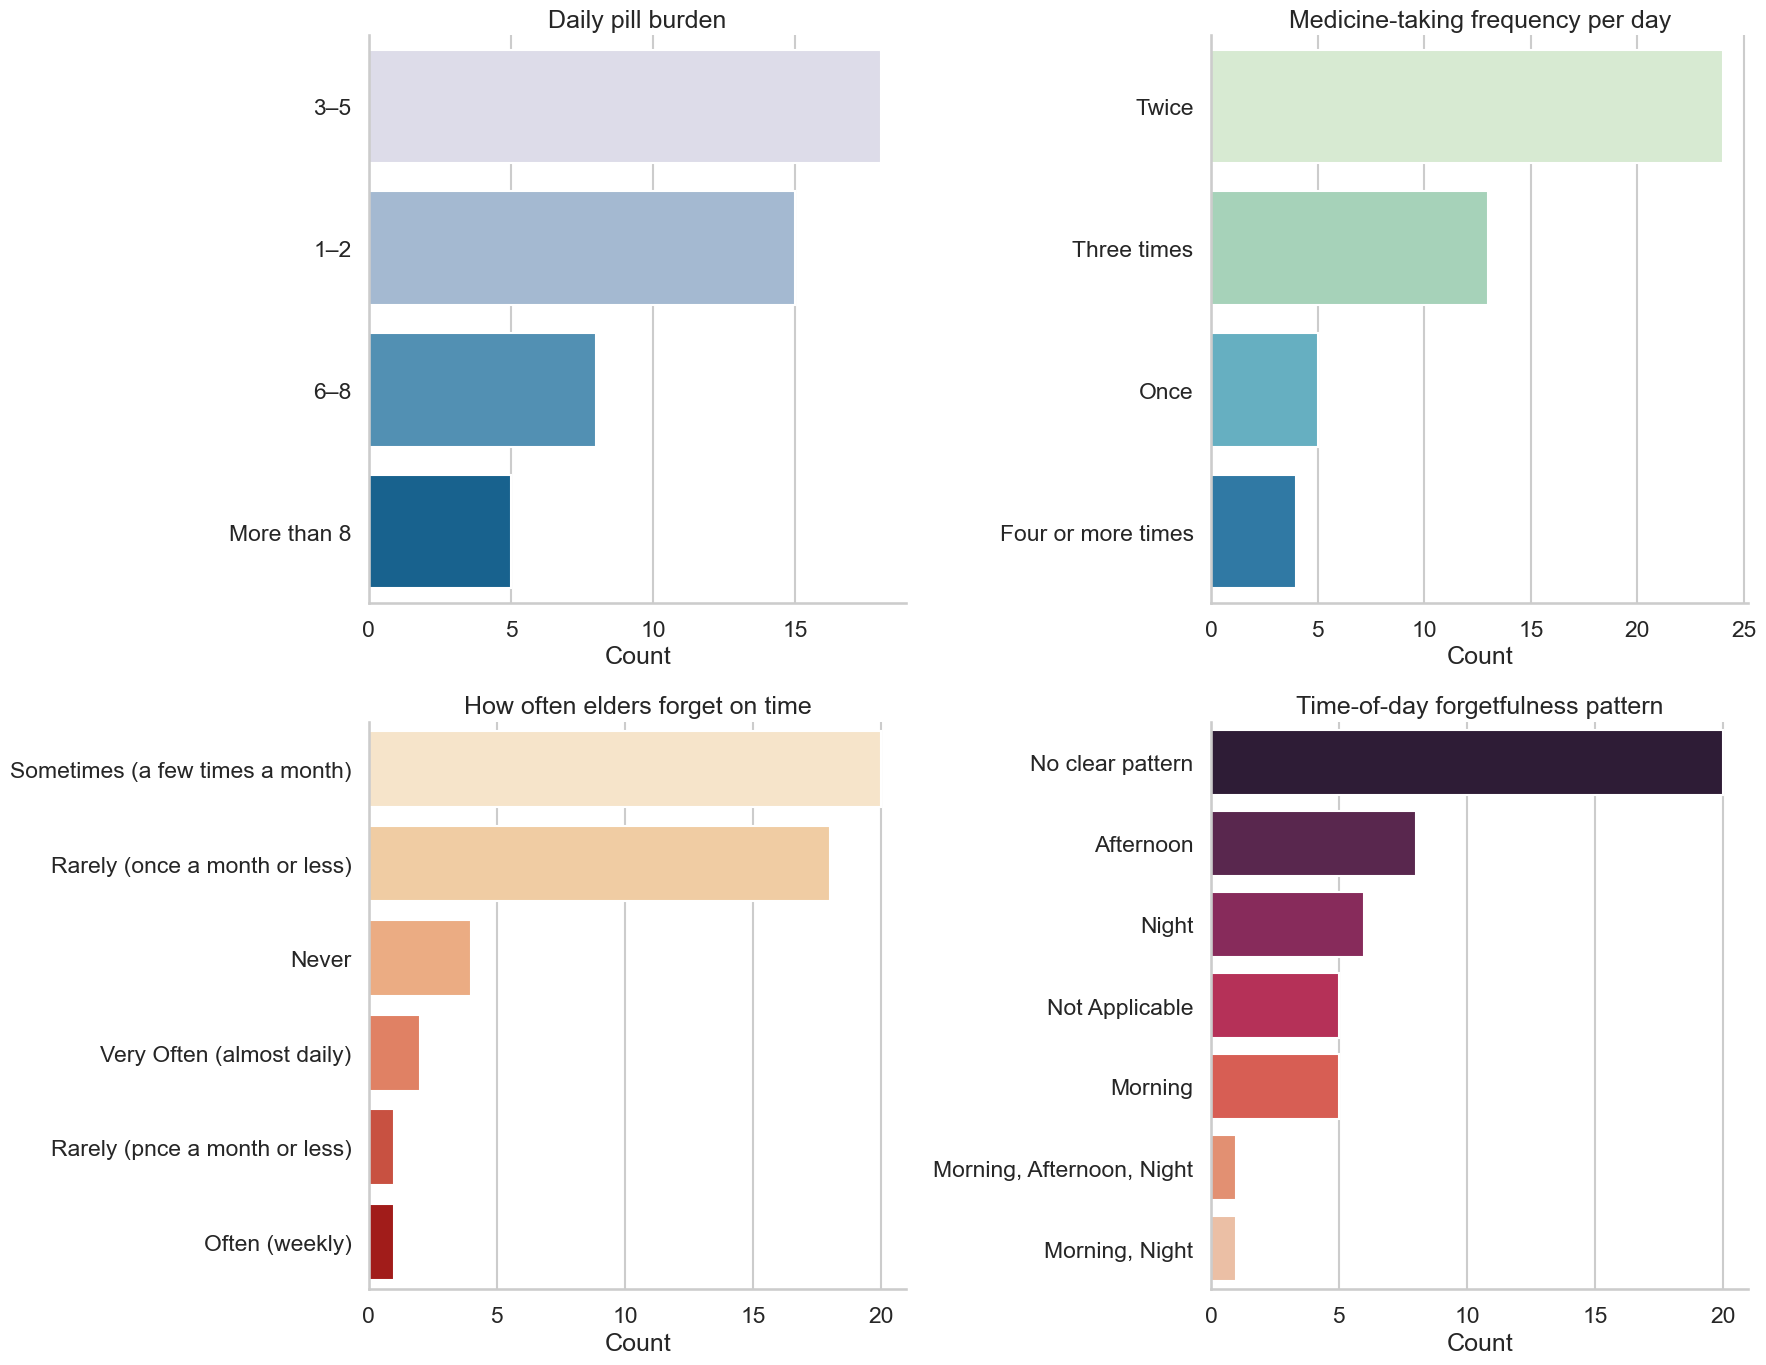

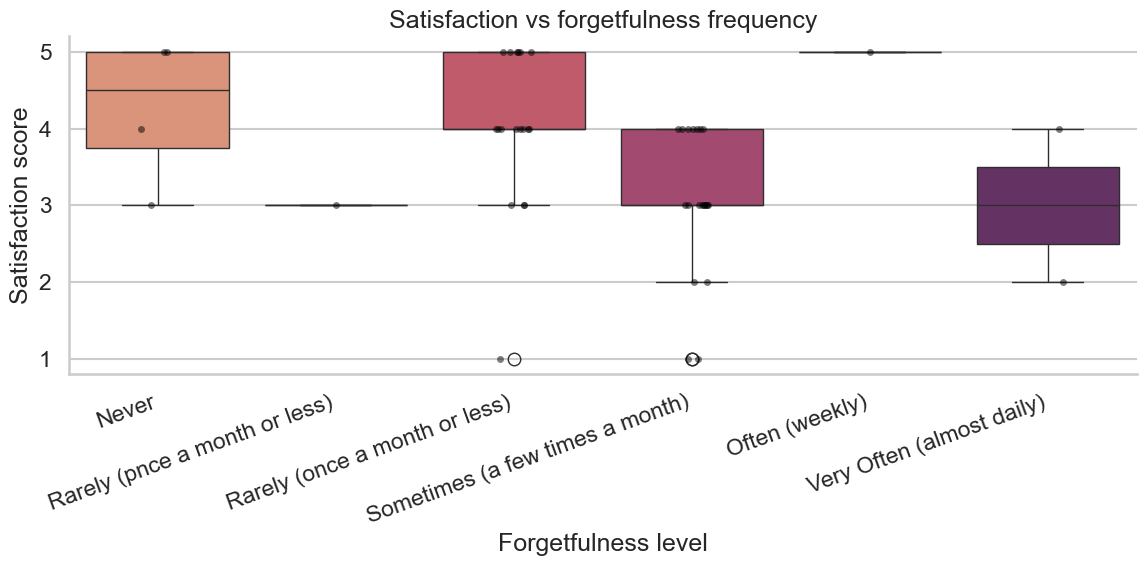

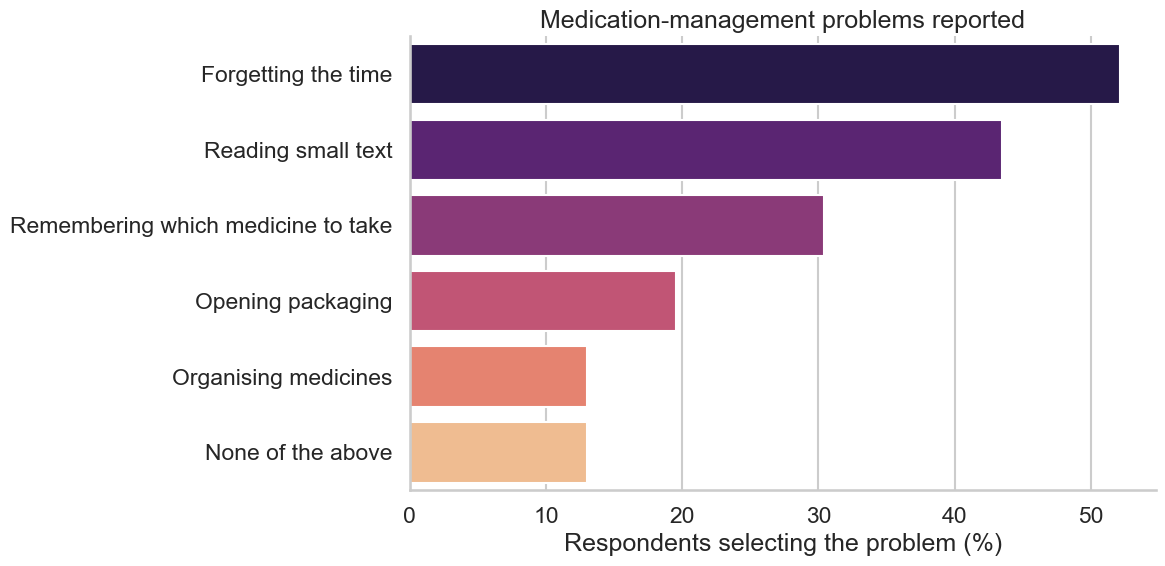

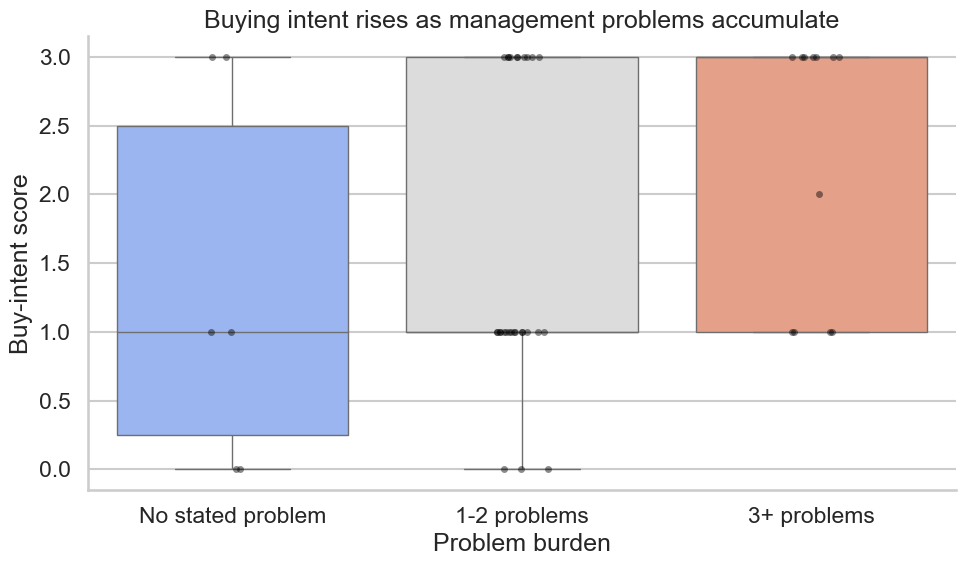

,pills_daily_num,times_daily_num,forgetfulness_num,satisfaction_num,problem_burden_score
mean,4.25,2.35,1.52,3.57,1.59
median,4.00,2.00,1.50,4.00,1.00
min,1.50,1.00,0.00,1.00,0.00
max,9.00,4.00,4.00,5.00,3.00


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.countplot(data=elder, y="pills_daily_raw", order=elder["pills_daily_raw"].value_counts().index, palette="PuBu", ax=axes[0, 0])
axes[0, 0].set_title("Daily pill burden")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("")

sns.countplot(data=elder, y="times_daily_raw", order=elder["times_daily_raw"].value_counts().index, palette="GnBu", ax=axes[0, 1])
axes[0, 1].set_title("Medicine-taking frequency per day")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("")

sns.countplot(data=elder, y="forgetfulness_raw", order=elder["forgetfulness_raw"].value_counts().index, palette="OrRd", ax=axes[1, 0])
axes[1, 0].set_title("How often elders forget on time")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("")

sns.countplot(data=elder, y="forget_time_raw", order=elder["forget_time_raw"].value_counts().index, palette="rocket", ax=axes[1, 1])
axes[1, 1].set_title("Time-of-day forgetfulness pattern")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

order = sorted(elder["forgetfulness_raw"].dropna().unique(), key=lambda x: FORGET_MAP.get(x, 99))
plt.figure(figsize=(12, 6))
sns.boxplot(data=elder, x="forgetfulness_raw", y="satisfaction_num", order=order, palette="flare")
sns.stripplot(data=elder, x="forgetfulness_raw", y="satisfaction_num", order=order, color="black", alpha=0.5)
plt.title("Satisfaction vs forgetfulness frequency")
plt.xlabel("Forgetfulness level")
plt.ylabel("Satisfaction score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

problem_rates = respondent_share(elder, "problem_list", PROBLEM_OPTIONS)
plt.figure(figsize=(12, 6))
sns.barplot(data=problem_rates, x="respondent_share_pct", y="category", palette="magma")
plt.title("Medication-management problems reported")
plt.xlabel("Respondents selecting the problem (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=elder,
    x="problem_burden_band",
    y="buy_intent_num",
    order=["No stated problem", "1-2 problems", "3+ problems"],
    palette="coolwarm",
)
sns.stripplot(
    data=elder,
    x="problem_burden_band",
    y="buy_intent_num",
    order=["No stated problem", "1-2 problems", "3+ problems"],
    color="black",
    alpha=0.45,
)
plt.title("Buying intent rises as management problems accumulate")
plt.xlabel("Problem burden")
plt.ylabel("Buy-intent score")
plt.tight_layout()
plt.show()

burden_summary = elder[
    [
        "pills_daily_num",
        "times_daily_num",
        "forgetfulness_num",
        "satisfaction_num",
        "problem_burden_score",
    ]
].agg(["mean", "median", "min", "max"]).round(2)
display(burden_summary)

The combination of pill load, number of intake moments, and reported problems helps identify where assistance is likely to be most valuable. Forgetting the time and difficulty reading packaging are especially actionable because they connect directly to reminder and interface design.

## 6. Current Medicine Storage, Organization, and Reminder Systems

These charts show how medicines are handled today and where the current system seems fragile.

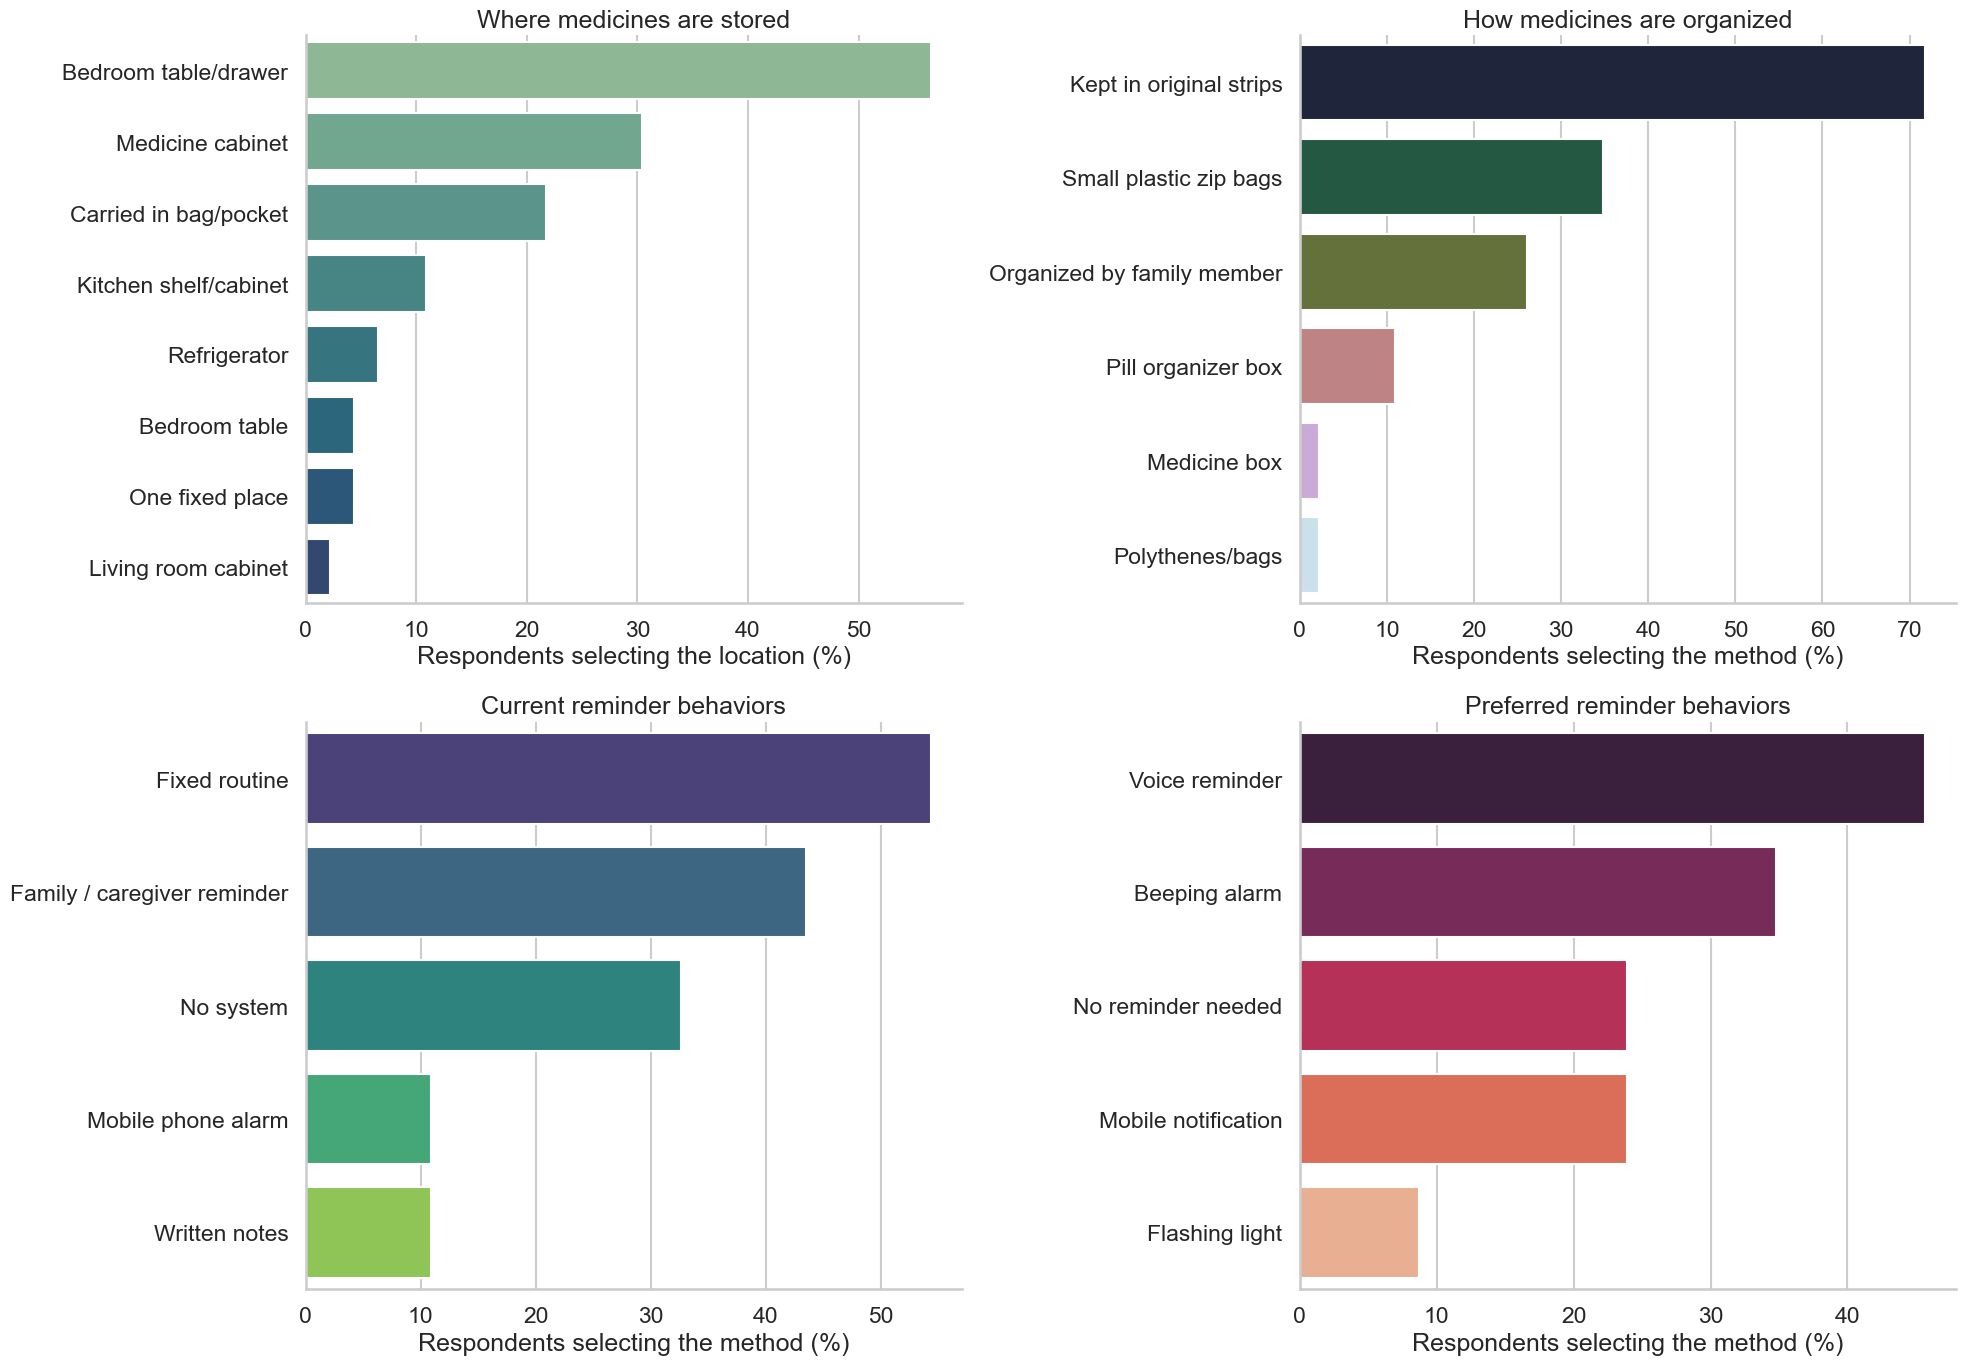

,category,respondent_share_pct_current,n_answers_current,respondent_share_pct_preferred,n_answers_preferred,gap_preferred_minus_current
8,Voice reminder,0.000000,0.0,45.652174,46.0,45.652174
0,Beeping alarm,0.000000,0.0,34.782609,46.0,34.782609
4,Mobile notification,0.000000,0.0,23.913043,46.0,23.913043
6,No reminder needed,0.000000,0.0,23.913043,46.0,23.913043
3,Flashing light,0.000000,0.0,8.695652,46.0,8.695652
5,Mobile phone alarm,10.869565,46.0,0.000000,0.0,-10.869565
9,Written notes,10.869565,46.0,0.000000,0.0,-10.869565
7,No system,32.608696,46.0,0.000000,0.0,-32.608696
1,Family / caregiver reminder,43.478261,46.0,0.000000,0.0,-43.478261
2,Fixed routine,54.347826,46.0,0.000000,0.0,-54.347826


In [8]:
storage_rates = respondent_share(
    elder,
    "storage_list",
    sorted({item for values in elder["storage_list"] if isinstance(values, list) for item in values}),
)
organization_rates = respondent_share(
    elder,
    "organization_list",
    sorted({item for values in elder["organization_list"] if isinstance(values, list) for item in values}),
)
current_reminder_rates = respondent_share(elder, "current_reminder_list", CURRENT_REMINDER_OPTIONS)
preferred_reminder_rates = respondent_share(elder, "preferred_reminder_list", PREFERRED_REMINDER_OPTIONS)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.barplot(data=storage_rates, x="respondent_share_pct", y="category", palette="crest", ax=axes[0, 0])
axes[0, 0].set_title("Where medicines are stored")
axes[0, 0].set_xlabel("Respondents selecting the location (%)")
axes[0, 0].set_ylabel("")

sns.barplot(data=organization_rates, x="respondent_share_pct", y="category", palette="cubehelix", ax=axes[0, 1])
axes[0, 1].set_title("How medicines are organized")
axes[0, 1].set_xlabel("Respondents selecting the method (%)")
axes[0, 1].set_ylabel("")

sns.barplot(data=current_reminder_rates, x="respondent_share_pct", y="category", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Current reminder behaviors")
axes[1, 0].set_xlabel("Respondents selecting the method (%)")
axes[1, 0].set_ylabel("")

sns.barplot(data=preferred_reminder_rates, x="respondent_share_pct", y="category", palette="rocket", ax=axes[1, 1])
axes[1, 1].set_title("Preferred reminder behaviors")
axes[1, 1].set_xlabel("Respondents selecting the method (%)")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

reminder_gap = current_reminder_rates.merge(
    preferred_reminder_rates, on="category", how="outer", suffixes=("_current", "_preferred")
).fillna(0)
reminder_gap["gap_preferred_minus_current"] = (
    reminder_gap["respondent_share_pct_preferred"] - reminder_gap["respondent_share_pct_current"]
)
display(reminder_gap.sort_values("gap_preferred_minus_current", ascending=False))

The gap table is useful because it separates what people do today from what they say would feel natural. In design terms, that difference often signals whitespace for a product concept.

## 7. Product Preference, Buying Intent, and Price Sensitivity

This part of the report converts the product-concept questions into market-facing signals: preferred format, desired storage horizon, purchase intent, and budget comfort.

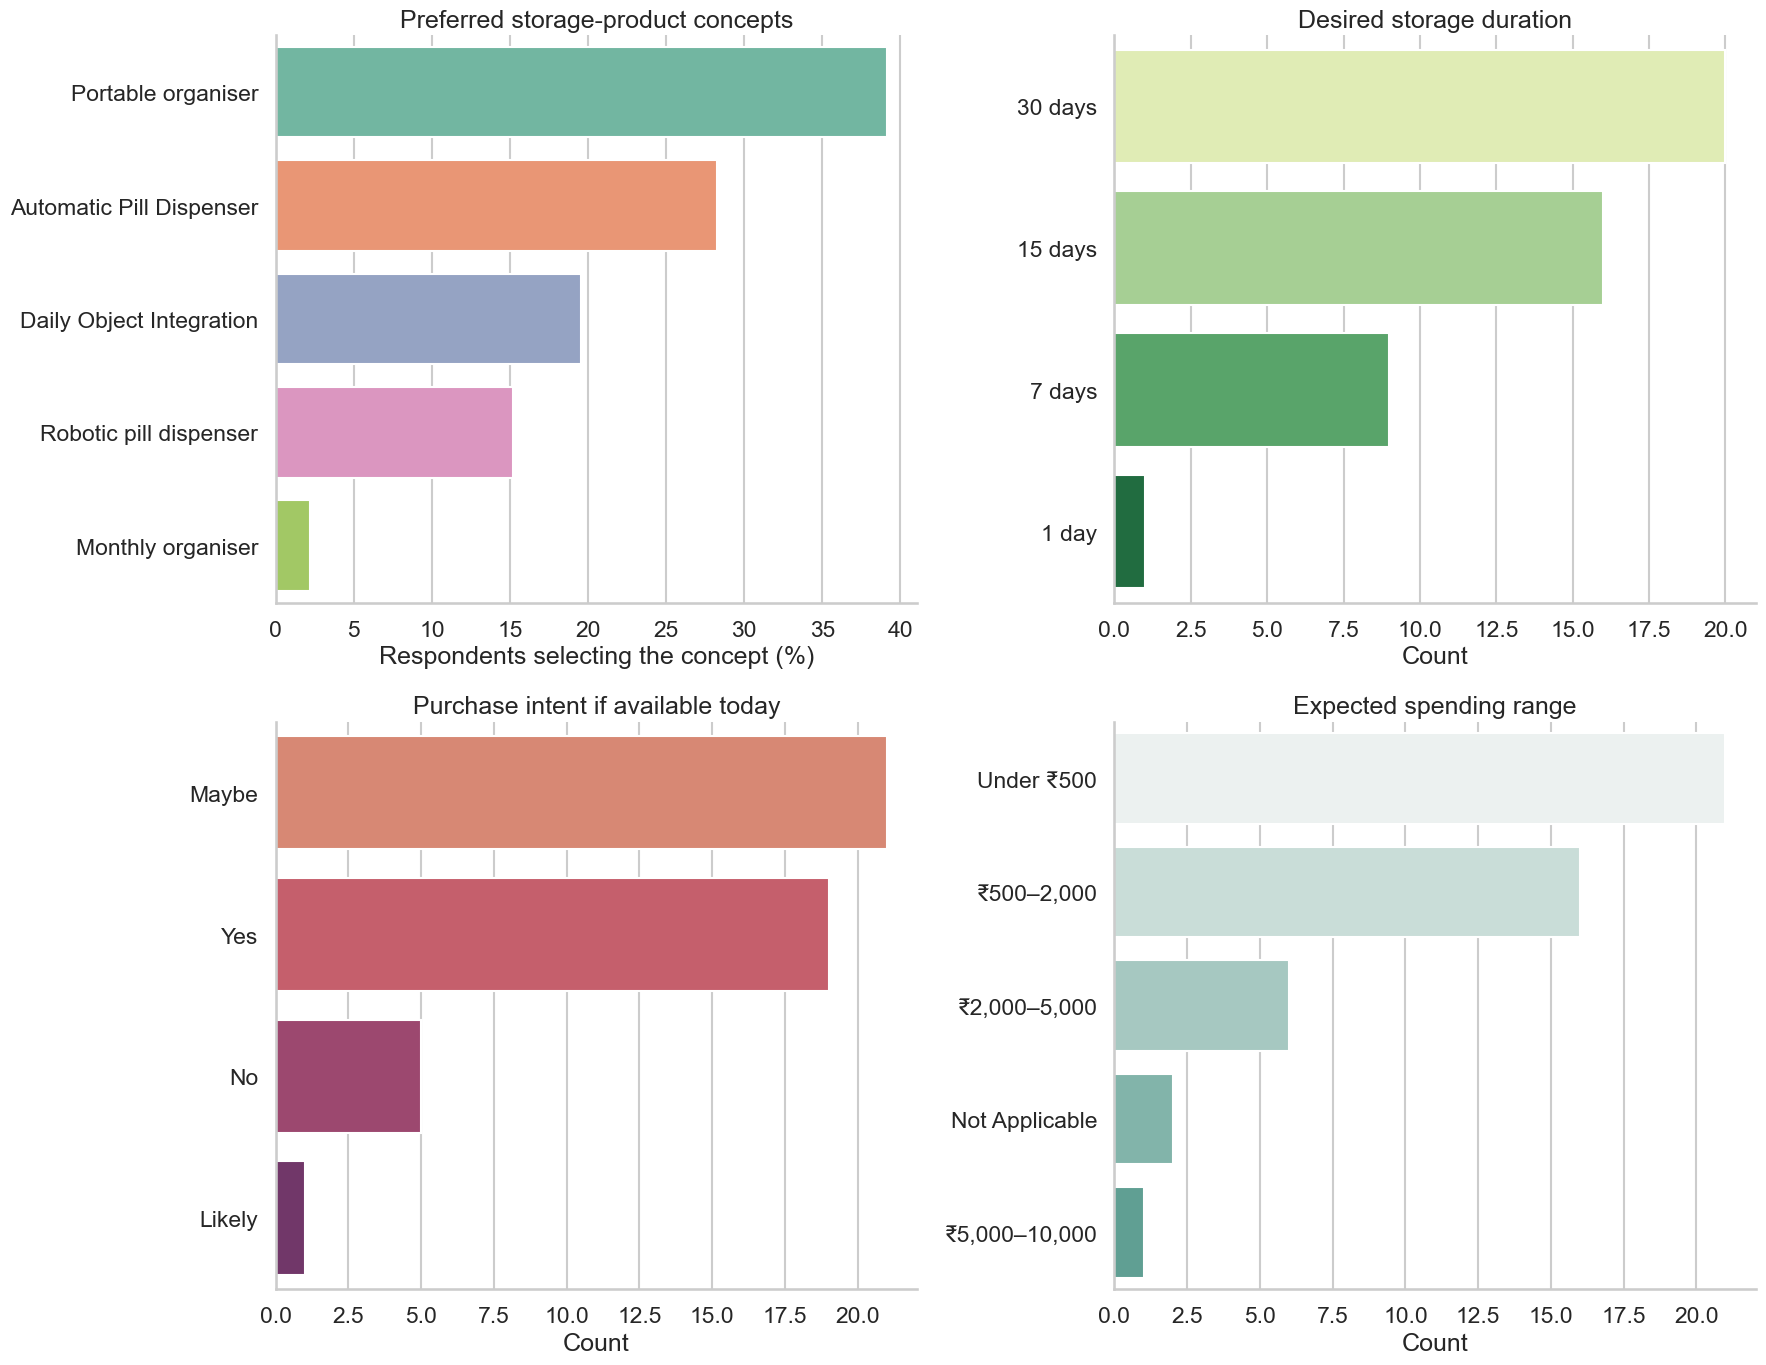

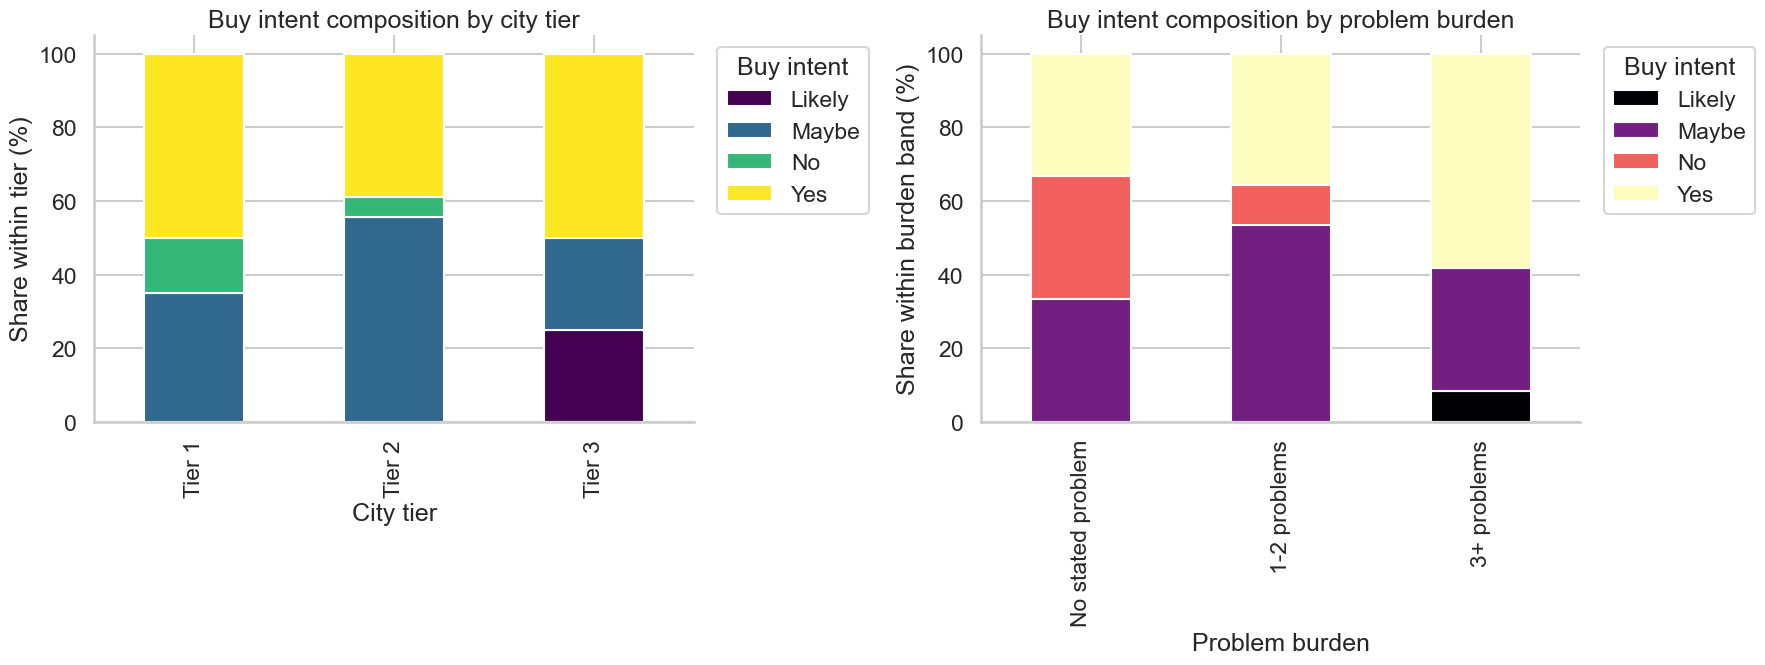

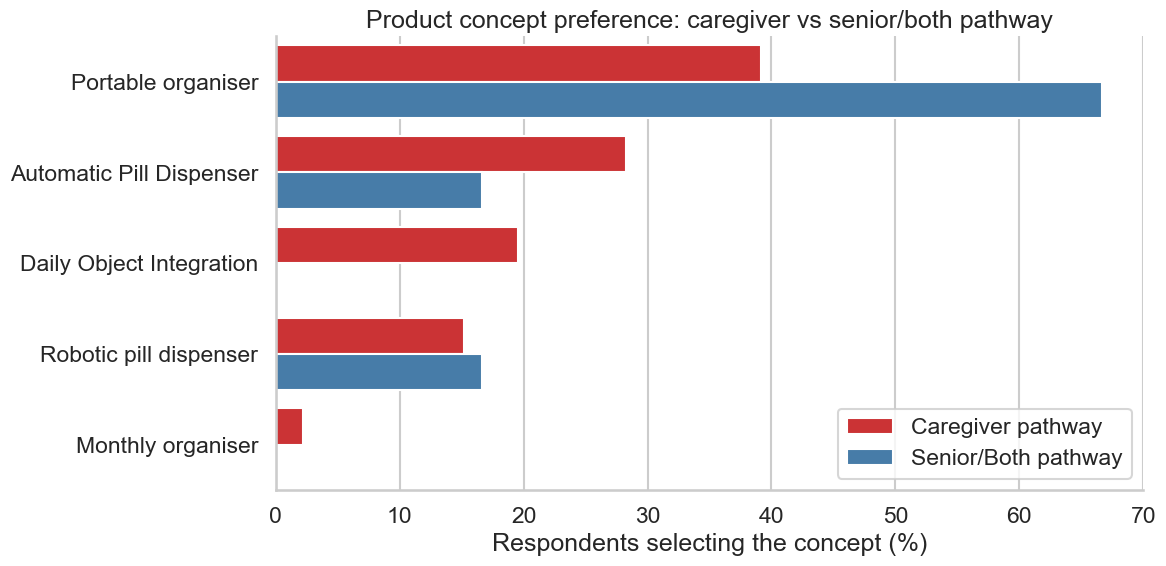

,days_pref_num,buy_intent_num,budget_num
mean,19.65,1.74,1.63
median,15.00,1.00,1.50


In [9]:
product_rates = respondent_share(elder, "product_pref_list", PRODUCT_OPTIONS)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(data=product_rates, x="respondent_share_pct", y="category", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Preferred storage-product concepts")
axes[0, 0].set_xlabel("Respondents selecting the concept (%)")
axes[0, 0].set_ylabel("")

sns.countplot(data=elder, y="days_pref_raw", order=elder["days_pref_raw"].value_counts().index, palette="YlGn", ax=axes[0, 1])
axes[0, 1].set_title("Desired storage duration")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("")

sns.countplot(data=elder, y="buy_intent_raw", order=elder["buy_intent_raw"].value_counts().index, palette="flare", ax=axes[1, 0])
axes[1, 0].set_title("Purchase intent if available today")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("")

sns.countplot(data=elder, y="budget_raw", order=elder["budget_raw"].value_counts().index, palette="light:#5A9", ax=axes[1, 1])
axes[1, 1].set_title("Expected spending range")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

buy_by_tier = pd.crosstab(elder["city_tier"], elder["buy_intent_raw"], normalize="index").mul(100).reindex(["Tier 1", "Tier 2", "Tier 3"])
buy_by_problem = pd.crosstab(elder["problem_burden_band"], elder["buy_intent_raw"], normalize="index").mul(100).reindex(["No stated problem", "1-2 problems", "3+ problems"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
buy_by_tier.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[0])
axes[0].set_title("Buy intent composition by city tier")
axes[0].set_xlabel("City tier")
axes[0].set_ylabel("Share within tier (%)")
axes[0].legend(title="Buy intent", bbox_to_anchor=(1.02, 1), loc="upper left")

buy_by_problem.plot(kind="bar", stacked=True, colormap="magma", ax=axes[1])
axes[1].set_title("Buy intent composition by problem burden")
axes[1].set_xlabel("Problem burden")
axes[1].set_ylabel("Share within burden band (%)")
axes[1].legend(title="Buy intent", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

product_compare = []
for label, frame in [("Caregiver pathway", elder), ("Senior/Both pathway", self_managed)]:
    shares = respondent_share(frame, "product_pref_list", PRODUCT_OPTIONS)
    shares["segment"] = label
    product_compare.append(shares)
product_compare = pd.concat(product_compare, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=product_compare, x="respondent_share_pct", y="category", hue="segment", palette="Set1")
plt.title("Product concept preference: caregiver vs senior/both pathway")
plt.xlabel("Respondents selecting the concept (%)")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

purchase_summary = elder[["days_pref_num", "buy_intent_num", "budget_num"]].agg(["mean", "median"]).round(2)
display(purchase_summary)

Budget distribution matters a lot here. If interest is concentrated below `₹2,000`, then a concept that sounds appealing but requires expensive automation may need a staged product strategy or modular pricing.

## 8. Correlations and Statistical Associations

Because most survey variables are ordinal or categorical, the report uses:

- **Spearman correlations** for ranked / encoded variables
- **Chi-square tests and Cramer's V** for selected categorical relationships

These results are exploratory and should be read cautiously because the sample is modest.

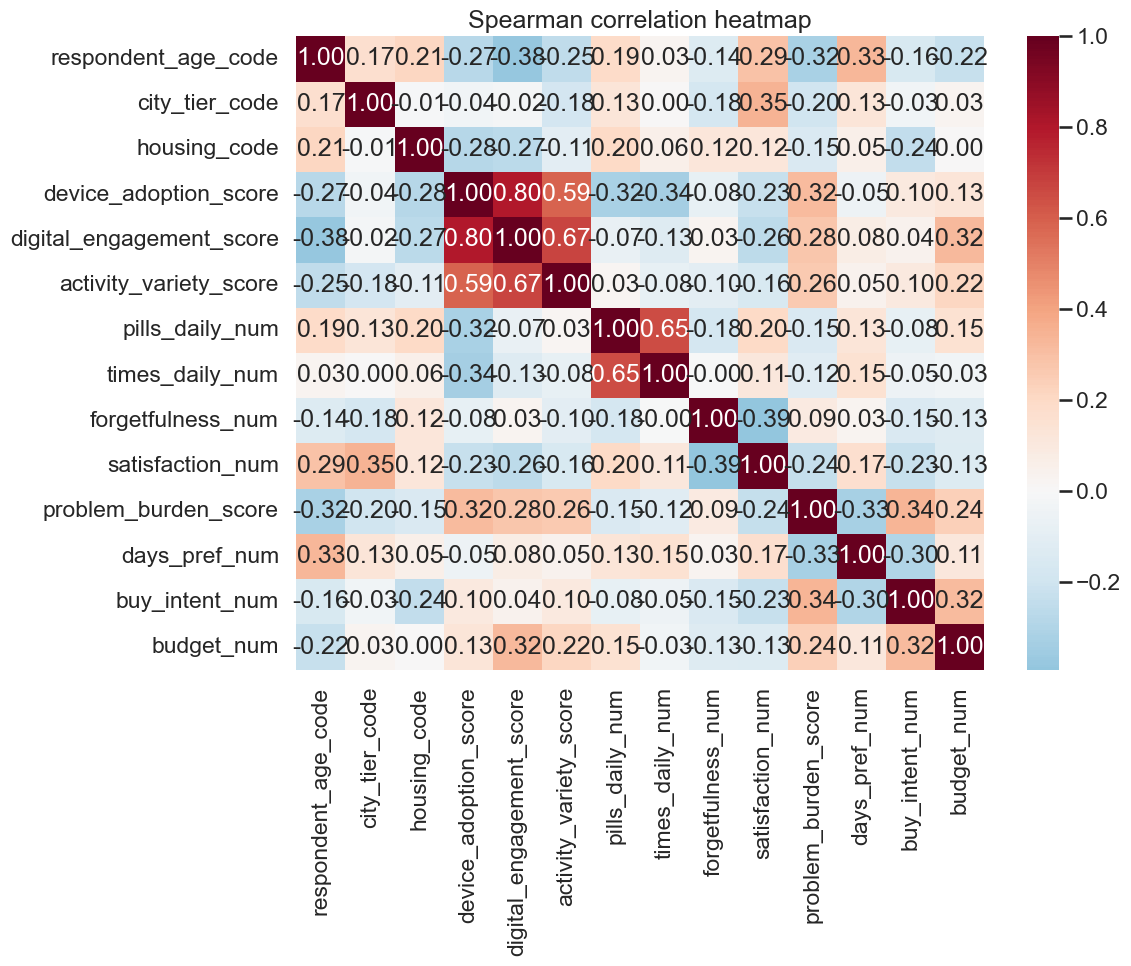

,left,right,rho,p_value,n,abs_rho
36,device_adoption_score,digital_engagement_score,0.798293,8.537317e-11,44,0.798293
46,digital_engagement_score,activity_variety_score,0.671673,5.996256e-07,44,0.671673
63,pills_daily_num,times_daily_num,0.648115,1.117935e-06,46,0.648115
37,device_adoption_score,activity_variety_score,0.590774,2.423718e-05,44,0.590774
76,forgetfulness_num,satisfaction_num,-0.391525,7.129763e-03,46,0.391525
3,respondent_age_code,digital_engagement_score,-0.382601,1.037196e-02,44,0.382601
20,city_tier_code,satisfaction_num,0.345003,2.524713e-02,42,0.345003
86,problem_burden_score,buy_intent_num,0.337259,2.190221e-02,46,0.337259
39,device_adoption_score,times_daily_num,-0.336731,2.370993e-02,45,0.336731
85,problem_burden_score,days_pref_num,-0.331409,2.445728e-02,46,0.331409


,left,right,n,chi2_p_value,cramers_v
2,housing_status,buy_intent_raw,45,0.000001,0.552039
3,digital_band,preferred_reminder_primary,44,0.008034,0.385950
0,city_tier,buy_intent_raw,46,0.055710,0.239374
5,forgetfulness_raw,preferred_reminder_primary,46,0.152810,0.188579
4,problem_burden_band,buy_intent_raw,46,0.170596,0.182254
1,city_tier,problem_burden_band,46,0.872443,0.000000


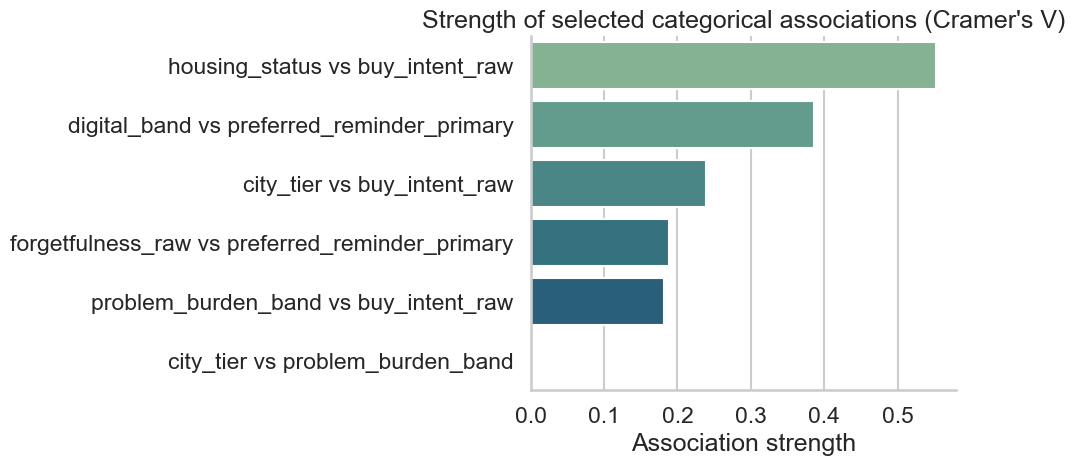

In [10]:
numeric_features = [
    "respondent_age_code",
    "city_tier_code",
    "housing_code",
    "device_adoption_score",
    "digital_engagement_score",
    "activity_variety_score",
    "pills_daily_num",
    "times_daily_num",
    "forgetfulness_num",
    "satisfaction_num",
    "problem_burden_score",
    "days_pref_num",
    "buy_intent_num",
    "budget_num",
]

corr = elder[numeric_features].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()

pair_results = []
for left, right in combinations(numeric_features, 2):
    subset = elder[[left, right]].dropna()
    if len(subset) < 8:
        continue
    rho, pvalue = spearmanr(subset[left], subset[right])
    pair_results.append({"left": left, "right": right, "rho": rho, "p_value": pvalue, "n": len(subset)})
pair_results = pd.DataFrame(pair_results)
pair_results["abs_rho"] = pair_results["rho"].abs()
display(pair_results.sort_values(["abs_rho", "p_value"], ascending=[False, True]).head(12))


def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)


categorical_tests = []
categorical_pairs = [
    ("city_tier", "buy_intent_raw"),
    ("city_tier", "problem_burden_band"),
    ("housing_status", "buy_intent_raw"),
    ("digital_band", "preferred_reminder_primary"),
    ("problem_burden_band", "buy_intent_raw"),
    ("forgetfulness_raw", "preferred_reminder_primary"),
]

for left, right in categorical_pairs:
    subset = elder[[left, right]].dropna()
    table = pd.crosstab(subset[left], subset[right])
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2, pvalue, _, _ = chi2_contingency(table)
    categorical_tests.append(
        {
            "left": left,
            "right": right,
            "n": int(table.to_numpy().sum()),
            "chi2_p_value": pvalue,
            "cramers_v": cramers_v(table),
        }
    )

categorical_tests = pd.DataFrame(categorical_tests).sort_values(["cramers_v", "chi2_p_value"], ascending=[False, True])
display(categorical_tests)

plt.figure(figsize=(10, 5))
plot_df = categorical_tests.copy()
plot_df["pair"] = plot_df["left"] + " vs " + plot_df["right"]
sns.barplot(data=plot_df, x="cramers_v", y="pair", palette="crest")
plt.title("Strength of selected categorical associations (Cramer's V)")
plt.xlabel("Association strength")
plt.ylabel("")
plt.tight_layout()
plt.show()

Correlation in this report should be read as a pattern-detection tool rather than proof of causality. Even so, it helps identify combinations worth designing for, such as heavier medicine burden plus higher product interest, or lower satisfaction plus more frequent forgetting.

## 9. Condensed Insight Summary and Design Implications

This final section turns the analysis into concrete takeaways that can be used for product thinking, segmentation, and discussion.

In [11]:
top_problem = respondent_share(elder, "problem_list", PROBLEM_OPTIONS).iloc[0]
top_product = respondent_share(elder, "product_pref_list", PRODUCT_OPTIONS).iloc[0]
top_preferred_reminder = respondent_share(elder, "preferred_reminder_list", PREFERRED_REMINDER_OPTIONS).iloc[0]
smartphone_rate = elder["device_smartphone"].mean() * 100
social_rate = elder["leisure_social_media"].mean() * 100
ott_rate = elder["leisure_ott_platforms"].mean() * 100
likely_buy_rate = elder["buy_intent_raw"].isin(["Likely", "Yes"]).mean() * 100
budget_under_2000 = elder["budget_num"].isin([1, 2]).mean() * 100
fixed_routine_rate = elder["current_reminder_list"].apply(lambda values: "Fixed routine" in values if isinstance(values, list) else np.nan).mean() * 100
family_reminder_rate = elder["current_reminder_list"].apply(lambda values: "Family / caregiver reminder" in values if isinstance(values, list) else np.nan).mean() * 100
no_reminder_rate = elder["preferred_reminder_list"].apply(lambda values: "No reminder needed" in values if isinstance(values, list) else np.nan).mean() * 100

summary_md = f'''
### Headline Findings

- The caregiver pathway contains **{len(elder)} intended respondents**, while the senior/both pathway contains **{len(self_managed)} intended respondents**.
- **{smartphone_rate:.1f}%** of caregiver-pathway answers report smartphone use for the elder profile, showing a strong base for at least partially digital interventions.
- Digital leisure is present but not universal: **{social_rate:.1f}%** mention social media and **{ott_rate:.1f}%** mention OTT usage.
- The most common management issue is **{top_problem['category']}** at **{top_problem['respondent_share_pct']:.1f}%** of respondents.
- Current remembering is driven more by habits and people than by formal systems: **Fixed routine = {fixed_routine_rate:.1f}%**, **Family / caregiver reminder = {family_reminder_rate:.1f}%**.
- The most comfortable reminder signal is **{top_preferred_reminder['category']}** at **{top_preferred_reminder['respondent_share_pct']:.1f}%**, while **No reminder needed** still appears in **{no_reminder_rate:.1f}%** of responses, so the market is not uniform.
- The most attractive product direction is **{top_product['category']}** at **{top_product['respondent_share_pct']:.1f}%**.
- **{likely_buy_rate:.1f}%** say they would be **Likely** or **Yes** to buying the concept if it were available today.
- Price sensitivity is real: **{budget_under_2000:.1f}%** of caregiver-pathway answers cluster at **₹2,000 or below**.

### Interpreting the Housing Question

The “owned / rented / family-owned / relative-owned” question works better as a **household stability and setup context variable** than as a city proxy. It can help explain:

- whether medicine storage is likely to be permanent or improvised
- whether a solution can assume a stable place in the home
- whether family involvement may be structurally high

### Practical Design Direction

- A **portable organiser** or low-complexity dispenser fits the strongest demand pattern.
- A **voice-led reminder layer** looks promising because it is more natural than forcing a pure notification-based workflow.
- A concept should support **moderate-to-heavy medicine burden** without assuming extreme technical comfort.
- A lower-cost entry version would likely matter more than a feature-maximal but expensive device.
- City tier can be used as a segmentation lens, but it should be framed as **contextual urbanity**, not as a deterministic explanation of behavior.
'''
display(Markdown(summary_md))

segment_table = pd.DataFrame(
    {
        "metric": [
            "Sample size",
            "Avg device adoption score",
            "Avg digital engagement score",
            "Likely/Yes buy intent %",
            "Budget at ₹2,000 or below %",
            "Mean satisfaction",
        ],
            "caregiver_pathway": [
            len(elder),
            round(elder["device_adoption_score"].mean(), 2),
            round(elder["digital_engagement_score"].mean(), 2),
            round(elder["buy_intent_raw"].isin(["Likely", "Yes"]).mean() * 100, 1),
            round(elder["budget_num"].isin([1, 2]).mean() * 100, 1),
            round(elder["satisfaction_num"].mean(), 2),
        ],
            "senior_both_pathway": [
            len(self_managed),
            round(self_managed["device_adoption_score"].mean(), 2),
            round(self_managed["digital_engagement_score"].mean(), 2),
            round(self_managed["buy_intent_raw"].isin(["Likely", "Yes"]).mean() * 100, 1),
            round(self_managed["budget_num"].isin([1, 2]).mean() * 100, 1),
            round(self_managed["satisfaction_num"].mean(), 2),
        ],
    }
)
display(segment_table)


### Headline Findings

- The caregiver pathway contains **48 intended respondents**, while the senior/both pathway contains **7 intended respondents**.
- **75.6%** of caregiver-pathway answers report smartphone use for the elder profile, showing a strong base for at least partially digital interventions.
- Digital leisure is present but not universal: **61.4%** mention social media and **20.5%** mention OTT usage.
- The most common management issue is **Forgetting the time** at **52.2%** of respondents.
- Current remembering is driven more by habits and people than by formal systems: **Fixed routine = 54.3%**, **Family / caregiver reminder = 43.5%**.
- The most comfortable reminder signal is **Voice reminder** at **45.7%**, while **No reminder needed** still appears in **23.9%** of responses, so the market is not uniform.
- The most attractive product direction is **Portable organiser** at **39.1%**.
- **41.7%** say they would be **Likely** or **Yes** to buying the concept if it were available today.
- Price sensitivity is real: **77.1%** of caregiver-pathway answers cluster at **₹2,000 or below**.

### Interpreting the Housing Question

The “owned / rented / family-owned / relative-owned” question works better as a **household stability and setup context variable** than as a city proxy. It can help explain:

- whether medicine storage is likely to be permanent or improvised
- whether a solution can assume a stable place in the home
- whether family involvement may be structurally high

### Practical Design Direction

- A **portable organiser** or low-complexity dispenser fits the strongest demand pattern.
- A **voice-led reminder layer** looks promising because it is more natural than forcing a pure notification-based workflow.
- A concept should support **moderate-to-heavy medicine burden** without assuming extreme technical comfort.
- A lower-cost entry version would likely matter more than a feature-maximal but expensive device.
- City tier can be used as a segmentation lens, but it should be framed as **contextual urbanity**, not as a deterministic explanation of behavior.


,metric,caregiver_pathway,senior_both_pathway
0,Sample size,48.00,7.00
1,Avg device adoption score,2.44,3.00
2,Avg digital engagement score,1.73,2.43
3,Likely/Yes buy intent %,41.70,28.60
4,"Budget at ₹2,000 or below %",77.10,85.70
5,Mean satisfaction,3.57,4.33
